In [122]:
import os
from pathlib import Path

print("Current Working Directory:", os.getcwd())
print("Datasets exists?", Path("Datasets").exists())

Current Working Directory: /Users/ishita/Coder/Proj/Skincare-Recommendation
Datasets exists? True


In [123]:
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

Loading the datasets 

In [124]:
DATA_DIR = Path("Datasets")

review_files = [
    DATA_DIR / "reviews_0-250.csv",
    DATA_DIR / "reviews_250-500.csv",
    DATA_DIR / "reviews_500-750.csv",
    DATA_DIR / "reviews_750-1250.csv",
    DATA_DIR / "reviews_1250-end.csv",
]

df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
df_reviews = df_reviews.drop(columns=["Unnamed: 0"], errors="ignore")

print("Reviews shape:", df_reviews.shape)
df_reviews.head()

/var/folders/7w/vrg67xp53xq_j1lvk8w5th380000gn/T/ipykernel_68582/3914178347.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
/var/folders/7w/vrg67xp53xq_j1lvk8w5th380000gn/T/ipykernel_68582/3914178347.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)
/var/folders/7w/vrg67xp53xq_j1lvk8w5th380000gn/T/ipykernel_68582/3914178347.py:11: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews = pd.concat([pd.read_csv(f) for f in review_files], ignore_index=True)


Reviews shape: (1094411, 18)


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


This contains product-level information such as category, brand, price, and ingredients.

In [125]:
df_products = pd.read_csv(DATA_DIR / "product_info.csv")

df_products = df_products.rename(
    columns={
        "rating": "avg_product_rating",
        "reviews": "num_reviews"
    }
)

print("Products shape:", df_products.shape)
df_products.head()

Products shape: (8494, 27)


,product_id,product_name,brand_id,brand_name,loves_count,avg_product_rating,num_reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


We only want skincare recommendations, so we filter the product table to skincare.

In [126]:
df_products = df_products[df_products["primary_category"] == "Skincare"].copy()

print("Skincare products:", df_products.shape)
print(df_products["primary_category"].value_counts(dropna=False))

Skincare products: (2420, 27)
primary_category
Skincare    2420
Name: count, dtype: int64


#### Merge reviews with skincare product info: This keeps only the reviews that belong to skincare products and attaches product metadata.

In [127]:
product_cols = [
    "product_id", "product_name", "brand_name", "ingredients", "price_usd",
    "highlights", "primary_category", "secondary_category", "tertiary_category",
    "avg_product_rating", "num_reviews", "loves_count", "sale_price_usd", "value_price_usd"
]

df_merged = df_reviews.merge(
    df_products[product_cols],
    on="product_id",
    how="inner"
)

print("Merged skincare review data shape:", df_merged.shape)
df_merged.head()

Merged skincare review data shape: (1094411, 31)


,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,...,price_usd_y,highlights,primary_category,secondary_category,tertiary_category,avg_product_rating,num_reviews,loves_count,sale_price_usd,value_price_usd
0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,...,19.0,['Clean at Sephora'],Skincare,Cleansers,NaN,5.0000,1.0,177,NaN,NaN
1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN
2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN
3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN
4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,...,24.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,4.3508,16118.0,1081315,NaN,NaN


In [128]:
# Check merged dataframe columns carefully
print("df_merged shape:", df_merged.shape)
print("\nColumns in df_merged:")
print(df_merged.columns.tolist())

# Check columns with suffixes created during merge
suffix_cols = [col for col in df_merged.columns if col.endswith("_x") or col.endswith("_y")]
print("\nColumns with _x/_y suffixes:")
print(suffix_cols)

df_merged shape: (1094411, 31)

Columns in df_merged:
['author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name_x', 'brand_name_x', 'price_usd_x', 'product_name_y', 'brand_name_y', 'ingredients', 'price_usd_y', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'avg_product_rating', 'num_reviews', 'loves_count', 'sale_price_usd', 'value_price_usd']

Columns with _x/_y suffixes:
['product_name_x', 'brand_name_x', 'price_usd_x', 'product_name_y', 'brand_name_y', 'price_usd_y']


In [129]:
# Make a clean merged dataframe for future modeling
df_merged_clean = df_merged.copy()

# Prefer product metadata columns from df_products where duplicate suffixes exist
rename_map = {}

for col in df_merged_clean.columns:
    if col.endswith("_y"):
        base_col = col[:-2]
        rename_map[col] = base_col

df_merged_clean = df_merged_clean.rename(columns=rename_map)

# Drop duplicate _x columns if matching clean column exists
drop_cols = []

for col in df_merged_clean.columns:
    if col.endswith("_x"):
        base_col = col[:-2]
        if base_col in df_merged_clean.columns:
            drop_cols.append(col)

df_merged_clean = df_merged_clean.drop(columns=drop_cols, errors="ignore")

print("Clean merged shape:", df_merged_clean.shape)
print("\nClean merged columns:")
print(df_merged_clean.columns.tolist())

Clean merged shape: (1094411, 28)

Clean merged columns:
['author_id', 'rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name', 'brand_name', 'ingredients', 'price_usd', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'avg_product_rating', 'num_reviews', 'loves_count', 'sale_price_usd', 'value_price_usd']


In [130]:
df_merged = df_merged_clean.copy()

#### Keep only the columns needed for collaborative filtering

For the rating model, the core information is:

- user id
- product id
- rating

We keep metadata separately for later display and possible hybrid extensions.

In [131]:
df_interactions = df_merged[["author_id", "product_id", "rating"]].copy()

# Convert IDs before deduplication and filtering
df_interactions["author_id"] = df_interactions["author_id"].astype(str)
df_interactions["product_id"] = df_interactions["product_id"].astype(str)
df_interactions["rating"] = pd.to_numeric(df_interactions["rating"], errors="coerce")

df_interactions = df_interactions.dropna(subset=["author_id", "product_id", "rating"])

print("Interaction rows before deduplication:", len(df_interactions))
df_interactions.head()

Interaction rows before deduplication: 1094411


,author_id,product_id,rating
0,1741593524,P504322,5
1,31423088263,P420652,1
2,5061282401,P420652,5
3,6083038851,P420652,5
4,47056667835,P420652,5


Sometimes the same user rated the same product more than once.
We collapse those duplicates into one average rating per user-product pair.

In [132]:
duplicate_pairs = df_interactions.duplicated(subset=["author_id", "product_id"]).sum()
print("Duplicate user-product pairs:", duplicate_pairs)

df_interactions = (
    df_interactions
    .groupby(["author_id", "product_id"], as_index=False)["rating"]
    .mean()
)

print("Interaction rows after deduplication:", len(df_interactions))
df_interactions.head()

Duplicate user-product pairs: 5525
Interaction rows after deduplication: 1088886


,author_id,product_id,rating
0,10000015049,P427417,5.0
1,1000001620,P467115,4.0
2,10000049623,P422003,5.0
3,10000060335,P269122,5.0
4,10000098796,P126301,5.0


### Filter to active users and products

This step reduces extreme sparsity.
We keep:
- users with at least 10 ratings
- products with at least 20 ratings

This makes collaborative filtering more stable.

In [133]:
MIN_USER_RATINGS = 10
MIN_PRODUCT_RATINGS = 20

user_counts = df_interactions["author_id"].value_counts()
product_counts = df_interactions["product_id"].value_counts()

active_users = user_counts[user_counts >= MIN_USER_RATINGS].index
active_products = product_counts[product_counts >= MIN_PRODUCT_RATINGS].index

df_cf = df_interactions[
    df_interactions["author_id"].isin(active_users) &
    df_interactions["product_id"].isin(active_products)
].copy()

print("Filtered interaction rows:", len(df_cf))
print("Filtered unique users:", df_cf["author_id"].nunique())
print("Filtered unique products:", df_cf["product_id"].nunique())

Filtered interaction rows: 176782
Filtered unique users: 9246
Filtered unique products: 1910


In [134]:
# Check data types
print(df_merged.dtypes)

# Convert important IDs to string in merged metadata as well
df_merged["author_id"] = df_merged["author_id"].astype(str)
df_merged["product_id"] = df_merged["product_id"].astype(str)

# Convert rating to numeric
df_merged["rating"] = pd.to_numeric(df_merged["rating"], errors="coerce")

# Convert submission_time to datetime if available
if "submission_time" in df_merged.columns:
    df_merged["submission_time"] = pd.to_datetime(df_merged["submission_time"], errors="coerce")

print("Data type cleanup complete.")

author_id                    object
rating                        int64
is_recommended              float64
helpfulness                 float64
total_feedback_count          int64
total_neg_feedback_count      int64
total_pos_feedback_count      int64
submission_time              object
review_text                  object
review_title                 object
skin_tone                    object
eye_color                    object
skin_type                    object
hair_color                   object
product_id                   object
product_name                 object
brand_name                   object
ingredients                  object
price_usd                   float64
highlights                   object
primary_category             object
secondary_category           object
tertiary_category            object
avg_product_rating          float64
num_reviews                 float64
loves_count                   int64
sale_price_usd              float64
value_price_usd             

In [135]:
def sparsity_summary(df, user_col="author_id", item_col="product_id", rating_col="rating", name="Data"):
    n_users = df[user_col].nunique()
    n_items = df[item_col].nunique()
    observed = len(df)
    total_possible = n_users * n_items
    missing = total_possible - observed
    missing_pct = 100 * missing / total_possible
    density_pct = 100 * observed / total_possible
    
    print(f" {name} ")
    print(f"Users: {n_users:,}")
    print(f"Products: {n_items:,}")
    print(f"Observed ratings: {observed:,}")
    print(f"Total possible user-product cells: {total_possible:,}")
    print(f"Missing cells: {missing:,}")
    print(f"Missing %: {missing_pct:.2f}%")
    print(f"Density %: {density_pct:.2f}%")
    print()

sparsity_summary(df_interactions, name="Before active-user/product filtering")
sparsity_summary(df_cf, name="After active-user/product filtering")

 Before active-user/product filtering 
Users: 503,216
Products: 2,351
Observed ratings: 1,088,886
Total possible user-product cells: 1,183,060,816
Missing cells: 1,181,971,930
Missing %: 99.91%
Density %: 0.09%

 After active-user/product filtering 
Users: 9,246
Products: 1,910
Observed ratings: 176,782
Total possible user-product cells: 17,659,860
Missing cells: 17,483,078
Missing %: 99.00%
Density %: 1.00%



In [136]:
print("Rating distribution after filtering:")
rating_dist_filtered = df_cf["rating"].value_counts().sort_index()
print(rating_dist_filtered)

print("\nRating distribution percentage after filtering:")
print((rating_dist_filtered / len(df_cf) * 100).round(2))

Rating distribution after filtering:
rating
1.000000      5085
1.500000        13
1.666667         1
2.000000      5782
2.500000        12
2.666667         1
3.000000     11360
3.333333         3
3.500000        21
4.000000     31795
4.250000         1
4.333333         1
4.400000         1
4.500000       105
4.666667         8
4.750000         1
5.000000    122592
Name: count, dtype: int64

Rating distribution percentage after filtering:
rating
1.000000     2.88
1.500000     0.01
1.666667     0.00
2.000000     3.27
2.500000     0.01
2.666667     0.00
3.000000     6.43
3.333333     0.00
3.500000     0.01
4.000000    17.99
4.250000     0.00
4.333333     0.00
4.400000     0.00
4.500000     0.06
4.666667     0.00
4.750000     0.00
5.000000    69.35
Name: count, dtype: float64


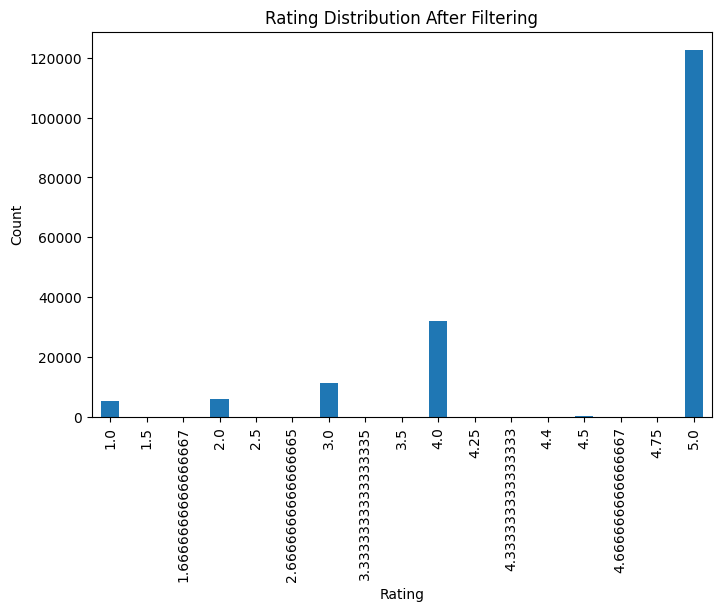

In [137]:
plt.figure(figsize=(8, 5))
df_cf["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution After Filtering")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

Ratings per user summary:
count    9246.000000
mean       19.119836
std        14.820816
min         6.000000
25%        11.000000
50%        14.000000
75%        20.000000
max       286.000000
Name: count, dtype: float64

Top 10 most active users:
author_id
1696370280     286
1288462295     199
7375781965     154
5060164185     150
1930716686     149
2330399812     149
1738022745     134
1492711942     134
10690040573    128
12640060683    118
Name: count, dtype: int64

Users with exactly 10 ratings:
1680


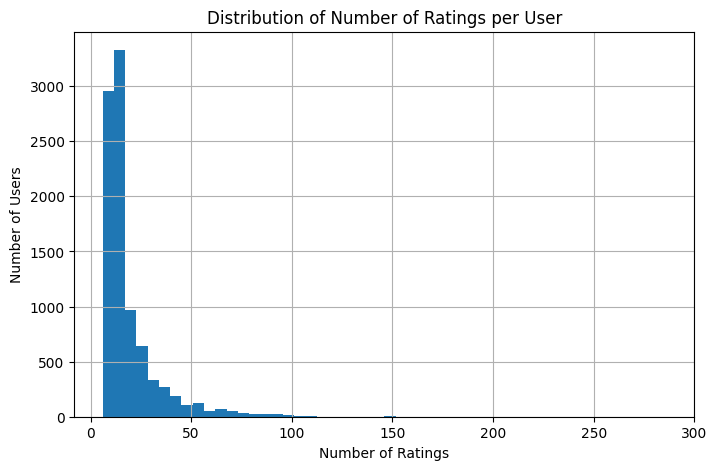

In [138]:
user_rating_counts = df_cf["author_id"].value_counts()

print("Ratings per user summary:")
print(user_rating_counts.describe())

print("\nTop 10 most active users:")
print(user_rating_counts.head(10))

print("\nUsers with exactly 10 ratings:")
print((user_rating_counts == 10).sum())

plt.figure(figsize=(8, 5))
user_rating_counts.hist(bins=50)
plt.title("Distribution of Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.show()

Ratings per product summary:
count    1910.000000
mean       92.556021
std       145.746397
min         1.000000
25%        12.000000
50%        42.000000
75%       110.000000
max      1577.000000
Name: count, dtype: float64

Top 10 most rated products:
product_id
P443352    1577
P423688    1577
P500633    1411
P270594    1361
P309308    1176
P476414    1076
P503936    1040
P479860     942
P442840     942
P420652     936
Name: count, dtype: int64

Products with exactly 20 ratings:
16


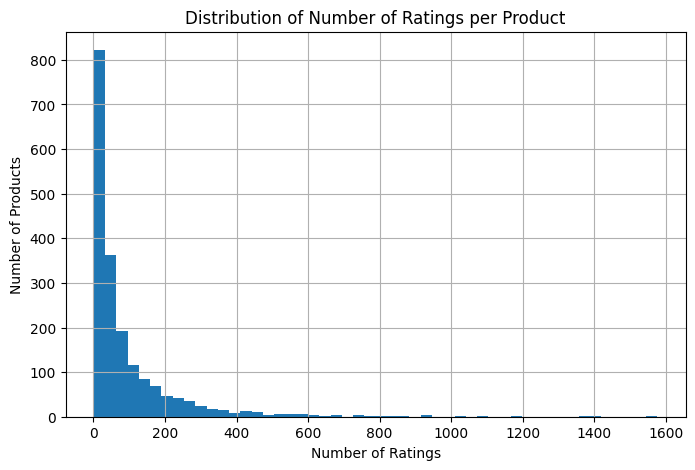

In [139]:
product_rating_counts = df_cf["product_id"].value_counts()

print("Ratings per product summary:")
print(product_rating_counts.describe())

print("\nTop 10 most rated products:")
print(product_rating_counts.head(10))

print("\nProducts with exactly 20 ratings:")
print((product_rating_counts == 20).sum())

plt.figure(figsize=(8, 5))
product_rating_counts.hist(bins=50)
plt.title("Distribution of Number of Ratings per Product")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")
plt.show()

In [140]:
metadata_cols = [
    "product_id",
    "product_name",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category",
    "price_usd",
    "ingredients",
    "highlights",
    "avg_product_rating",
    "num_reviews",
    "loves_count"
]

metadata_cols = [col for col in metadata_cols if col in df_merged.columns]

df_product_metadata = (
    df_merged[metadata_cols]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

df_cf_with_meta = df_cf.merge(
    df_product_metadata,
    on="product_id",
    how="left"
)

print("Filtered interactions with metadata shape:", df_cf_with_meta.shape)
df_cf_with_meta.head()

Filtered interactions with metadata shape: (176782, 14)


,author_id,product_id,rating,product_name,brand_name,primary_category,secondary_category,tertiary_category,price_usd,ingredients,highlights,avg_product_rating,num_reviews,loves_count
0,10000770719,P404338,4.0,Whipped Argan Oil Face Butter,Josie Maran,Skincare,Moisturizers,Moisturizers,45.0,"['Aqua (Water), Argania Spinosa (Argan) Kernel...",NaN,4.1421,1393.0,40417
1,10000770719,P439061,5.0,Glow2OH Dark Spot Toner,OLEHENRIKSEN,Skincare,Cleansers,Toners,35.0,"['Water, Glycolic Acid, Hamamelis Virginiana (...","['Vegan', 'Good for: Dullness/Uneven Texture',...",4.1922,2955.0,182201
2,10000770719,P447212,5.0,Hyaluronic Serum,Dr. Barbara Sturm,Skincare,Treatments,Face Serums,320.0,"['Water, Butylene Glycol, Lactobacillus/Portul...","['Good for: Dark Circles', 'Good for: Dryness'...",3.9386,879.0,7257
3,10000770719,P447781,5.0,Face Cream,Dr. Barbara Sturm,Skincare,Moisturizers,Moisturizers,225.0,"['Water, Octyldodecanol, C12-15 Alkyl Benzoate...","['Best for Oily, Combo, Normal Skin', 'Good fo...",4.2407,810.0,4738
4,10000770719,P447782,5.0,Glow Drops,Dr. Barbara Sturm,Skincare,Treatments,Face Serums,150.0,"['Water, Prunus Amygdalus Dulcis (Sweet Almond...","['Good for: Dark Circles', 'Good for: Dullness...",4.0601,815.0,8905


In [141]:
print("Top 15 brands in filtered interaction data:")
print(df_cf_with_meta["brand_name"].value_counts().head(15))

print("\nTop secondary categories:")
print(df_cf_with_meta["secondary_category"].value_counts(dropna=False).head(15))

print("\nTop tertiary categories:")
print(df_cf_with_meta["tertiary_category"].value_counts(dropna=False).head(15))

Top 15 brands in filtered interaction data:
brand_name
Glow Recipe            9117
Dermalogica            8972
fresh                  7933
Farmacy                6255
Sunday Riley           5875
Tatcha                 5561
Drunk Elephant         5466
Skinfix                5364
Murad                  4833
Sulwhasoo              3722
Supergoop!             3674
Caudalie               3430
SEPHORA COLLECTION     3353
The Ordinary           3305
Youth To The People    3227
Name: count, dtype: int64

Top secondary categories:
secondary_category
Moisturizers              46795
Treatments                41661
Cleansers                 26353
Eye Care                  14422
Mini Size                 14027
Masks                     11144
Sunscreen                  7852
Lip Balms & Treatments     6092
Wellness                   2755
Value & Gift Sets          2189
Self Tanners               1896
High Tech Tools            1596
Name: count, dtype: int64

Top tertiary categories:
tertiary_category

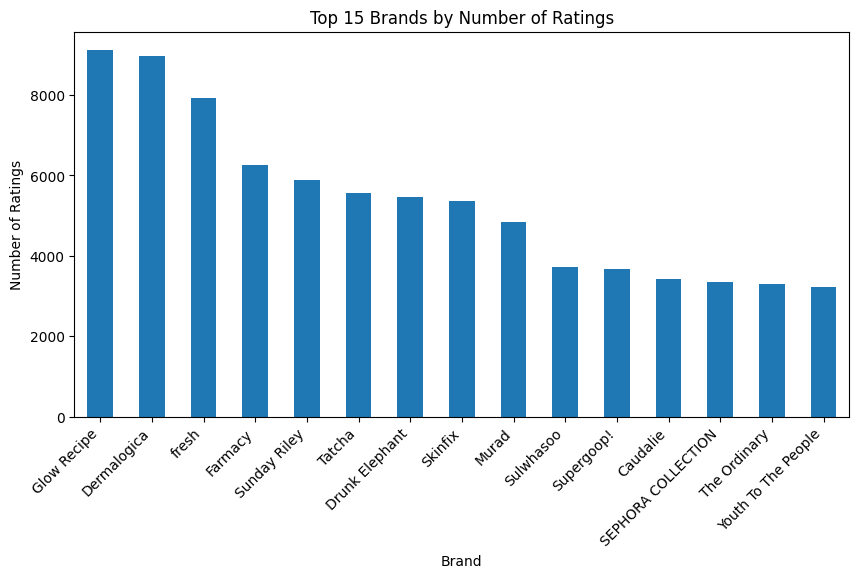

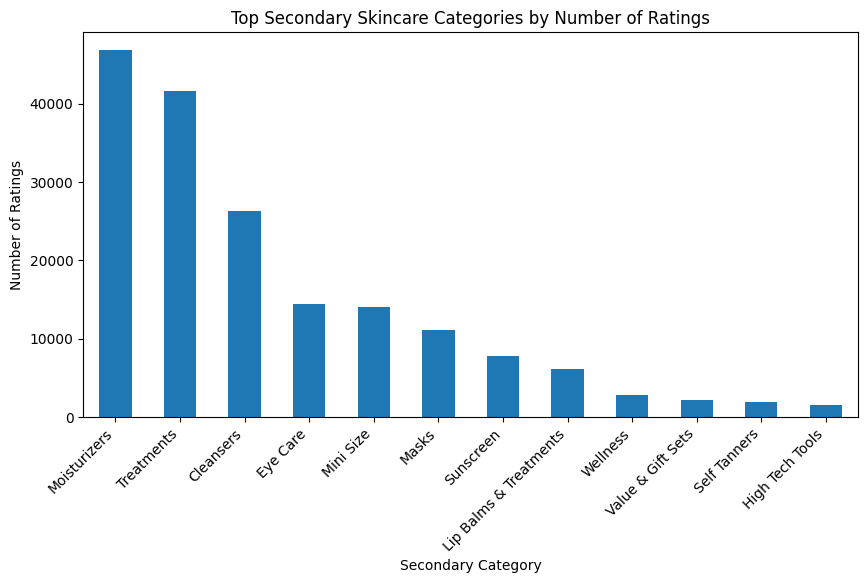

In [142]:
plt.figure(figsize=(10, 5))
df_cf_with_meta["brand_name"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Brands by Number of Ratings")
plt.xlabel("Brand")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45, ha="right")
plt.show()

plt.figure(figsize=(10, 5))
df_cf_with_meta["secondary_category"].value_counts().head(15).plot(kind="bar")
plt.title("Top Secondary Skincare Categories by Number of Ratings")
plt.xlabel("Secondary Category")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=45, ha="right")
plt.show()

In [143]:
brand_summary = (
    df_cf_with_meta
    .groupby("brand_name")
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count"),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

brand_summary_filtered = brand_summary[brand_summary["rating_count"] >= 100]

print("Top brands by average rating, minimum 100 ratings:")
brand_summary_filtered.sort_values("mean_rating", ascending=False).head(15)

Top brands by average rating, minimum 100 ratings:


,brand_name,mean_rating,rating_count,unique_products
71,MARA,4.887534,738,10
16,DAMDAM,4.793956,728,7
108,StriVectin,4.785304,871,19
46,Hanni,4.766578,377,3
70,MACRENE actives,4.763285,207,5
19,Dermalogica,4.757133,8972,45
28,EADEM,4.752852,263,3
85,PMD,4.750000,332,9
7,Bobbi Brown,4.749046,1572,7
32,FaceGym,4.738854,785,16


In [144]:
category_summary = (
    df_cf_with_meta
    .groupby("secondary_category")
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count"),
        unique_products=("product_id", "nunique")
    )
    .reset_index()
)

category_summary_filtered = category_summary[category_summary["rating_count"] >= 100]

print("Top categories by average rating, minimum 100 ratings:")
category_summary_filtered.sort_values("mean_rating", ascending=False).head(15)

Top categories by average rating, minimum 100 ratings:


,secondary_category,mean_rating,rating_count,unique_products
10,Value & Gift Sets,4.689813,2189,62
2,High Tech Tools,4.556391,1596,52
9,Treatments,4.508501,41661,404
7,Self Tanners,4.499209,1896,41
6,Moisturizers,4.486487,46795,464
1,Eye Care,4.483821,14422,161
8,Sunscreen,4.475739,7852,88
4,Masks,4.450601,11144,132
0,Cleansers,4.449411,26353,302
3,Lip Balms & Treatments,4.445103,6092,56


In [145]:
product_popularity = (
    df_cf_with_meta
    .groupby(["product_id", "product_name", "brand_name"])
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count")
    )
    .reset_index()
    .sort_values(["rating_count", "mean_rating"], ascending=[False, False])
)

print("Most rated products:")
product_popularity.head(20)

Most rated products:


,product_id,product_name,brand_name,mean_rating,rating_count
423,P423688,Daily Microfoliant Exfoliator,Dermalogica,4.786937,1577
705,P443352,Mini Daily Microfoliant Exfoliator,Dermalogica,4.786937,1577
1704,P500633,Tea Elixir Niacinamide & Hyaluronic Acid Anti-...,fresh,4.794472,1411
62,P270594,Vitamin Enriched Face Base Priming Moisturizer,Bobbi Brown,4.786921,1361
82,P309308,Good Genes All-In-One AHA Lactic Acid Treatment,Sunday Riley,4.596939,1176
1438,P476414,5 Stars Retinol + Niacinamide Eye Serum,Sunday Riley,4.792751,1076
1818,P503936,Black Tea Anti-Aging Moisturizer with Retinol-...,fresh,4.849038,1040
688,P442840,Barrier+ Triple Lipid-Peptide Face Cream,Skinfix,4.643312,942
1514,P479860,Mini Barrier+ Triple Lipid-Peptide Face Cream,Skinfix,4.643312,942
367,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,4.327635,936


In [146]:
important_content_cols = [
    "product_name",
    "brand_name",
    "ingredients",
    "highlights",
    "secondary_category",
    "tertiary_category",
    "price_usd",
    "review_text",
    "review_title",
    "skin_type",
    "skin_tone",
    "eye_color",
    "hair_color"
]

important_content_cols = [col for col in important_content_cols if col in df_merged.columns]

missing_content_summary = (
    df_merged[important_content_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_content_pct = (
    df_merged[important_content_cols]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

content_missing_table = pd.DataFrame({
    "missing_count": missing_content_summary,
    "missing_percent": missing_content_pct
})

content_missing_table

,missing_count,missing_percent
review_title,310654,28.39
hair_color,226768,20.72
eye_color,209628,19.15
skin_tone,170539,15.58
tertiary_category,161256,14.73
highlights,113936,10.41
skin_type,111557,10.19
ingredients,22025,2.01
review_text,1444,0.13
product_name,0,0.00


Review text length summary:
count    1.094411e+06
mean     3.201541e+02
std      2.315846e+02
min      0.000000e+00
25%      1.710000e+02
50%      2.630000e+02
75%      4.020000e+02
max      6.448000e+03
Name: review_text_length, dtype: float64

Review word count summary:
count    1.094411e+06
mean     6.045960e+01
std      4.350890e+01
min      0.000000e+00
25%      3.200000e+01
50%      5.000000e+01
75%      7.600000e+01
max      1.216000e+03
Name: review_word_count, dtype: float64


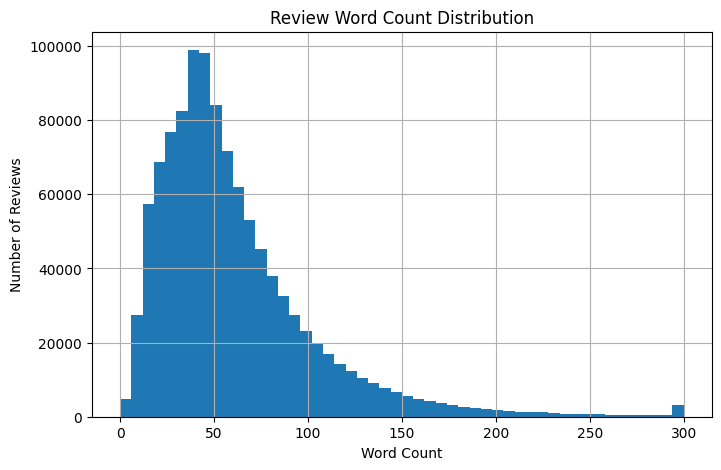

In [147]:
if "review_text" in df_merged.columns:
    df_merged["review_text_length"] = df_merged["review_text"].fillna("").str.len()
    df_merged["review_word_count"] = df_merged["review_text"].fillna("").str.split().str.len()

    print("Review text length summary:")
    print(df_merged["review_text_length"].describe())

    print("\nReview word count summary:")
    print(df_merged["review_word_count"].describe())

    plt.figure(figsize=(8, 5))
    df_merged["review_word_count"].clip(upper=300).hist(bins=50)
    plt.title("Review Word Count Distribution")
    plt.xlabel("Word Count")
    plt.ylabel("Number of Reviews")
    plt.show()

In [148]:
raw_user_counts = df_interactions["author_id"].value_counts()
raw_product_counts = df_interactions["product_id"].value_counts()

cold_start_summary = pd.DataFrame({
    "metric": [
        "Users with 1 rating",
        "Users with fewer than 5 ratings",
        "Users with fewer than 10 ratings",
        "Products with 1 rating",
        "Products with fewer than 5 ratings",
        "Products with fewer than 20 ratings"
    ],
    "count": [
        (raw_user_counts == 1).sum(),
        (raw_user_counts < 5).sum(),
        (raw_user_counts < 10).sum(),
        (raw_product_counts == 1).sum(),
        (raw_product_counts < 5).sum(),
        (raw_product_counts < 20).sum()
    ],
    "percent": [
        100 * (raw_user_counts == 1).sum() / len(raw_user_counts),
        100 * (raw_user_counts < 5).sum() / len(raw_user_counts),
        100 * (raw_user_counts < 10).sum() / len(raw_user_counts),
        100 * (raw_product_counts == 1).sum() / len(raw_product_counts),
        100 * (raw_product_counts < 5).sum() / len(raw_product_counts),
        100 * (raw_product_counts < 20).sum() / len(raw_product_counts)
    ]
})

cold_start_summary

,metric,count,percent
0,Users with 1 rating,294111,58.446274
1,Users with fewer than 5 ratings,462783,91.965081
2,Users with fewer than 10 ratings,493970,98.162618
3,Products with 1 rating,24,1.020842
4,Products with fewer than 5 ratings,127,5.401957
5,Products with fewer than 20 ratings,417,17.737133


In [149]:
# Build final modeling dataframe BEFORE summary_table

df_model = df_cf.copy()

# Make sure ID columns are strings and rating is numeric
df_model["author_id"] = df_model["author_id"].astype(str)
df_model["product_id"] = df_model["product_id"].astype(str)
df_model["rating"] = pd.to_numeric(df_model["rating"], errors="coerce")

# Drop any remaining missing values
df_model = df_model.dropna(subset=["author_id", "product_id", "rating"]).copy()

print("Final modeling dataframe shape:", df_model.shape)
print("Unique users:", df_model["author_id"].nunique())
print("Unique products:", df_model["product_id"].nunique())
print("Observed ratings:", len(df_model))

# Create full user-product matrix
user_product_matrix = df_model.pivot(
    index="author_id",
    columns="product_id",
    values="rating"
)

print("User-product matrix shape:", user_product_matrix.shape)
print("Number of users:", user_product_matrix.shape[0])
print("Number of products:", user_product_matrix.shape[1])

Final modeling dataframe shape: (176782, 3)
Unique users: 9246
Unique products: 1910
Observed ratings: 176782
User-product matrix shape: (9246, 1910)
Number of users: 9246
Number of products: 1910


In [150]:
summary_table = pd.DataFrame({
    "Stage": [
        "Raw reviews",
        "Skincare products",
        "Merged skincare reviews",
        "Deduplicated interactions",
        "Filtered collaborative filtering data",
        "User-product matrix"
    ],
    "Rows / Users": [
        len(df_reviews),
        len(df_products),
        len(df_merged),
        len(df_interactions),
        df_cf["author_id"].nunique(),
        user_product_matrix.shape[0]
    ],
    "Columns / Products": [
        df_reviews.shape[1],
        df_products.shape[1],
        df_merged.shape[1],
        df_interactions.shape[1],
        df_cf["product_id"].nunique(),
        user_product_matrix.shape[1]
    ],
    "Notes": [
        "All review files combined",
        "Filtered to primary_category == Skincare",
        "Reviews merged with skincare metadata",
        "Duplicate user-product ratings averaged",
        "Users >= 10 ratings, products >= 20 ratings",
        "Sparse matrix for recommender models"
    ]
})

summary_table

,Stage,Rows / Users,Columns / Products,Notes
0,Raw reviews,1094411,18,All review files combined
1,Skincare products,2420,27,Filtered to primary_category == Skincare
2,Merged skincare reviews,1094411,30,Reviews merged with skincare metadata
3,Deduplicated interactions,1088886,3,Duplicate user-product ratings averaged
4,Filtered collaborative filtering data,9246,1910,"Users >= 10 ratings, products >= 20 ratings"
5,User-product matrix,9246,1910,Sparse matrix for recommender models


### Build a user-product matrix 

In [151]:
# Final collaborative filtering dataframe
df_model = df_cf.copy()

# Make sure ID columns are strings and rating is numeric
df_model["author_id"] = df_model["author_id"].astype(str)
df_model["product_id"] = df_model["product_id"].astype(str)
df_model["rating"] = pd.to_numeric(df_model["rating"], errors="coerce")

# Drop any remaining missing values
df_model = df_model.dropna(subset=["author_id", "product_id", "rating"]).copy()

print("Final modeling dataframe shape:", df_model.shape)
print("Unique users:", df_model["author_id"].nunique())
print("Unique products:", df_model["product_id"].nunique())
print("Observed ratings:", len(df_model))

df_model.head()

Final modeling dataframe shape: (176782, 3)
Unique users: 9246
Unique products: 1910
Observed ratings: 176782


,author_id,product_id,rating
51,10000770719,P404338,4.0
52,10000770719,P439061,5.0
53,10000770719,P447212,5.0
54,10000770719,P447781,5.0
55,10000770719,P447782,5.0


In [152]:
# Create user-product matrix
user_product_matrix = df_model.pivot(
    index="author_id",
    columns="product_id",
    values="rating"
)

print("User-product matrix shape:", user_product_matrix.shape)
print("Number of users:", user_product_matrix.shape[0])
print("Number of products:", user_product_matrix.shape[1])

user_product_matrix.head()

User-product matrix shape: (9246, 1910)
Number of users: 9246
Number of products: 1910


product_id,P107306,P114902,P12045,P122651,P122661,P122718,P122727,P122762,P122767,P122774,...,P54509,P6028,P7365,P7880,P91627362,P94421,P94812,P9939,P9940,P9941
author_id,,,,,,,,,,,,,,,,,,,,,
10000770719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000235057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN
10003868106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10005368592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10005786204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [153]:
n_users, n_products = user_product_matrix.shape

total_cells = n_users * n_products
observed_cells = user_product_matrix.notna().sum().sum()
missing_cells = total_cells - observed_cells

density_pct = 100 * observed_cells / total_cells
sparsity_pct = 100 * missing_cells / total_cells

print("Total possible user-product cells:", total_cells)
print("Observed ratings:", observed_cells)
print("Missing cells:", missing_cells)
print(f"Density: {density_pct:.2f}%")
print(f"Sparsity: {sparsity_pct:.2f}%")

Total possible user-product cells: 17659860
Observed ratings: 176782
Missing cells: 17483078
Density: 1.00%
Sparsity: 99.00%


### Convert the dataset into train/test/validation split

In [154]:
from sklearn.model_selection import train_test_split

def user_holdout_split(
    df,
    user_col="author_id",
    item_col="product_id",
    rating_col="rating",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
):
    train_parts = []
    val_parts = []
    test_parts = []

    for user_id, user_df in df.groupby(user_col):
        user_df = user_df.sample(frac=1, random_state=random_state)

        n_ratings = len(user_df)

        # Number of ratings for validation and test
        n_test = max(1, int(round(test_size * n_ratings)))
        n_val = max(1, int(round(val_size * n_ratings)))

        # Make sure train still has at least 1 rating
        if n_ratings - n_val - n_test < 1:
            n_test = 1
            n_val = 0

        test_df = user_df.iloc[:n_test]
        val_df = user_df.iloc[n_test:n_test + n_val]
        train_df = user_df.iloc[n_test + n_val:]

        train_parts.append(train_df)
        val_parts.append(val_df)
        test_parts.append(test_df)

    train_df = pd.concat(train_parts).reset_index(drop=True)
    val_df = pd.concat(val_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)

    return train_df, val_df, test_df


train_df, val_df, test_df = user_holdout_split(
    df_model,
    user_col="author_id",
    item_col="product_id",
    rating_col="rating",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain users:", train_df["author_id"].nunique())
print("Validation users:", val_df["author_id"].nunique())
print("Test users:", test_df["author_id"].nunique())

print("\nTrain products:", train_df["product_id"].nunique())
print("Validation products:", val_df["product_id"].nunique())
print("Test products:", test_df["product_id"].nunique())

Train shape: (121096, 3)
Validation shape: (27843, 3)
Test shape: (27843, 3)

Train users: 9246
Validation users: 9246
Test users: 9246

Train products: 1890
Validation products: 1685
Test products: 1695


In [155]:
total_rows = len(df_model)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(train_df), len(val_df), len(test_df)],
    "Percentage": [
        100 * len(train_df) / total_rows,
        100 * len(val_df) / total_rows,
        100 * len(test_df) / total_rows
    ],
    "Unique Users": [
        train_df["author_id"].nunique(),
        val_df["author_id"].nunique(),
        test_df["author_id"].nunique()
    ],
    "Unique Products": [
        train_df["product_id"].nunique(),
        val_df["product_id"].nunique(),
        test_df["product_id"].nunique()
    ]
})

split_summary

,Split,Rows,Percentage,Unique Users,Unique Products
0,Train,121096,68.500187,9246,1890
1,Validation,27843,15.749907,9246,1685
2,Test,27843,15.749907,9246,1695


In [156]:
train_users = set(train_df["author_id"])
val_users = set(val_df["author_id"])
test_users = set(test_df["author_id"])

print("Validation users missing from train:", len(val_users - train_users))
print("Test users missing from train:", len(test_users - train_users))

Validation users missing from train: 0
Test users missing from train: 0


In [157]:
train_products = set(train_df["product_id"])
val_products = set(val_df["product_id"])
test_products = set(test_df["product_id"])

print("Validation products missing from train:", len(val_products - train_products))
print("Test products missing from train:", len(test_products - train_products))

Validation products missing from train: 15
Test products missing from train: 11


In [158]:
# Keep only validation/test rows where product is present in training
known_train_products = set(train_df["product_id"])

val_df_clean = val_df[val_df["product_id"].isin(known_train_products)].copy()
test_df_clean = test_df[test_df["product_id"].isin(known_train_products)].copy()

print("Original validation rows:", len(val_df))
print("Clean validation rows:", len(val_df_clean))
print("Dropped validation rows:", len(val_df) - len(val_df_clean))

print("\nOriginal test rows:", len(test_df))
print("Clean test rows:", len(test_df_clean))
print("Dropped test rows:", len(test_df) - len(test_df_clean))

Original validation rows: 27843
Clean validation rows: 27818
Dropped validation rows: 25

Original test rows: 27843
Clean test rows: 27822
Dropped test rows: 21


In [159]:
val_df = val_df_clean.copy()
test_df = test_df_clean.copy()

In [160]:
train_matrix = train_df.pivot(
    index="author_id",
    columns="product_id",
    values="rating"
)

print("Train matrix shape:", train_matrix.shape)
print("Train observed ratings:", train_matrix.notna().sum().sum())

train_matrix.head()

Train matrix shape: (9246, 1890)
Train observed ratings: 121096


product_id,P107306,P114902,P12045,P122661,P122718,P122727,P122762,P122767,P122774,P122782,...,P54509,P6028,P7365,P7880,P91627362,P94421,P94812,P9939,P9940,P9941
author_id,,,,,,,,,,,,,,,,,,,,,
10000770719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1000235057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10003868106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10005368592,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10005786204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [161]:
all_users = sorted(df_model["author_id"].unique())
all_products = sorted(df_model["product_id"].unique())

train_matrix_full = train_matrix.reindex(
    index=all_users,
    columns=all_products
)

print("Full train matrix shape:", train_matrix_full.shape)
print("Train observed ratings:", train_matrix_full.notna().sum().sum())
print("Missing values in train matrix:", train_matrix_full.isna().sum().sum())

Full train matrix shape: (9246, 1910)
Train observed ratings: 121096
Missing values in train matrix: 17538764


In [162]:
val_user_items = (
    val_df
    .groupby("author_id")["product_id"]
    .apply(list)
    .to_dict()
)

test_user_items = (
    test_df
    .groupby("author_id")["product_id"]
    .apply(list)
    .to_dict()
)

print("Users in validation dictionary:", len(val_user_items))
print("Users in test dictionary:", len(test_user_items))

Users in validation dictionary: 9246
Users in test dictionary: 9246


In [163]:
sample_user = list(test_user_items.keys())[0]

print("Sample user:", sample_user)
print("Held-out test products:", test_user_items[sample_user])

Sample user: 10000770719
Held-out test products: ['P477413', 'P455924']


In [164]:
val_actual = val_df.set_index(["author_id", "product_id"])["rating"].to_dict()
test_actual = test_df.set_index(["author_id", "product_id"])["rating"].to_dict()

print("Validation actual ratings:", len(val_actual))
print("Test actual ratings:", len(test_actual))

Validation actual ratings: 27818
Test actual ratings: 27822


In [ ]:
train_df.to_csv("ishita_output/train_interactions.csv", index=False)
val_df.to_csv("ishita_outputs/val_interactions.csv", index=False)
test_df.to_csv("ishita_outputs/test_interactions.csv", index=False)

print("Saved train, validation, and test interaction files.")

Saved train, validation, and test interaction files.


In [166]:
print("Final sanity check")
print("=" * 40)

print("Original df_model rows:", len(df_model))
print("Train + val + test rows:", len(train_df) + len(val_df) + len(test_df))

print("\nTrain users:", train_df["author_id"].nunique())
print("Validation users:", val_df["author_id"].nunique())
print("Test users:", test_df["author_id"].nunique())

print("\nTrain products:", train_df["product_id"].nunique())
print("Validation products:", val_df["product_id"].nunique())
print("Test products:", test_df["product_id"].nunique())

print("\nValidation users missing from train:", len(set(val_df["author_id"]) - set(train_df["author_id"])))
print("Test users missing from train:", len(set(test_df["author_id"]) - set(train_df["author_id"])))

print("\nValidation products missing from train:", len(set(val_df["product_id"]) - set(train_df["product_id"])))
print("Test products missing from train:", len(set(test_df["product_id"]) - set(train_df["product_id"])))

Final sanity check
Original df_model rows: 176782
Train + val + test rows: 176736

Train users: 9246
Validation users: 9246
Test users: 9246

Train products: 1890
Validation products: 1670
Test products: 1684

Validation users missing from train: 0
Test users missing from train: 0

Validation products missing from train: 0
Test products missing from train: 0


### Baseline Model

Predicted rating = overall average rating + how generous the user is + how popular the product is + brand/category effect.

In [167]:
# Product metadata columns we may use
metadata_cols = [
    "product_id",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category"
]

metadata_cols = [col for col in metadata_cols if col in df_merged.columns]

product_meta = (
    df_merged[metadata_cols]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

product_meta["product_id"] = product_meta["product_id"].astype(str)

print("Product metadata shape:", product_meta.shape)
product_meta.head()

Product metadata shape: (2351, 5)


,product_id,brand_name,primary_category,secondary_category,tertiary_category
0,P504322,NUDESTIX,Skincare,Cleansers,NaN
1,P420652,LANEIGE,Skincare,Lip Balms & Treatments,NaN
16139,P7880,fresh,Skincare,Cleansers,Face Wash & Cleansers
24875,P218700,Josie Maran,Skincare,Moisturizers,Face Oils
32638,P248407,First Aid Beauty,Skincare,Moisturizers,Moisturizers


In [168]:
train_base = train_df.merge(product_meta, on="product_id", how="left")
val_base = val_df.merge(product_meta, on="product_id", how="left")
test_base = test_df.merge(product_meta, on="product_id", how="left")

print("Train with metadata:", train_base.shape)
print("Validation with metadata:", val_base.shape)
print("Test with metadata:", test_base.shape)

train_base.head()

Train with metadata: (121096, 7)
Validation with metadata: (27818, 7)
Test with metadata: (27822, 7)


,author_id,product_id,rating,brand_name,primary_category,secondary_category,tertiary_category
0,10000770719,P447785,5.0,Dr. Barbara Sturm,Skincare,Eye Care,Eye Creams & Treatments
1,10000770719,P447212,5.0,Dr. Barbara Sturm,Skincare,Treatments,Face Serums
2,10000770719,P439061,5.0,OLEHENRIKSEN,Skincare,Cleansers,Toners
3,10000770719,P501254,5.0,Glow Recipe,Skincare,Treatments,Facial Peels
4,10000770719,P447782,5.0,Dr. Barbara Sturm,Skincare,Treatments,Face Serums


In [169]:
cols_to_check = [
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category"
]

cols_to_check = [col for col in cols_to_check if col in train_base.columns]

print("Missing values in train metadata:")
print(train_base[cols_to_check].isna().sum())

print("\nMissing values in validation metadata:")
print(val_base[cols_to_check].isna().sum())

print("\nMissing values in test metadata:")
print(test_base[cols_to_check].isna().sum())

Missing values in train metadata:
brand_name                0
primary_category          0
secondary_category        0
tertiary_category     16135
dtype: int64

Missing values in validation metadata:
brand_name               0
primary_category         0
secondary_category       0
tertiary_category     3482
dtype: int64

Missing values in test metadata:
brand_name               0
primary_category         0
secondary_category       0
tertiary_category     3479
dtype: int64


In [170]:
for df in [train_base, val_base, test_base]:
    for col in cols_to_check:
        df[col] = df[col].fillna("Unknown")

In [171]:
global_mean = train_base["rating"].mean()

print("Global mean rating:", global_mean)

Global mean rating: 4.477989088546828


In [172]:
prediction = global_mean

In [173]:
user_bias = (
    train_base
    .groupby("author_id")["rating"]
    .mean()
    - global_mean
)

user_bias = user_bias.to_dict()

print("Number of user biases:", len(user_bias))

# Show sample
list(user_bias.items())[:5]

Number of user biases: 9246


[('10000770719', 0.5220109114531724),
 ('1000235057', -0.8241429347006739),
 ('10003868106', 0.09343948288174353),
 ('10005368592', -1.4779890885468276),
 ('10005786204', -0.47798908854682765)]

In [174]:
def compute_smoothed_bias(df, group_col, rating_col="rating", global_mean=None, alpha=20):
    """
    Smoothed bias:
    group_bias = (sum_ratings - n * global_mean) / (n + alpha)

    alpha controls shrinkage:
    - larger alpha pulls small groups closer to 0
    - smaller alpha trusts group averages more
    """
    if global_mean is None:
        global_mean = df[rating_col].mean()
    
    group_stats = (
        df
        .groupby(group_col)[rating_col]
        .agg(["sum", "count"])
    )
    
    group_stats["bias"] = (
        group_stats["sum"] - group_stats["count"] * global_mean
    ) / (group_stats["count"] + alpha)
    
    return group_stats["bias"].to_dict()

In [175]:
product_bias = compute_smoothed_bias(
    train_base,
    group_col="product_id",
    rating_col="rating",
    global_mean=global_mean,
    alpha=20
)

print("Number of product biases:", len(product_bias))
list(product_bias.items())[:5]

Number of product biases: 1890


[('P107306', -0.018868141984368824),
 ('P114902', -0.05559781770936553),
 ('P12045', 0.00014537124239435016),
 ('P122661', 0.04533515190886206),
 ('P122718', 0.023543777374622248)]

In [176]:
brand_bias = compute_smoothed_bias(
    train_base,
    group_col="brand_name",
    rating_col="rating",
    global_mean=global_mean,
    alpha=20
)

print("Number of brand biases:", len(brand_bias))
list(brand_bias.items())[:5]

Number of brand biases: 138


[('Algenist', -0.00630426062901546),
 ('Alpha-H', -0.059847008434079606),
 ('Anastasia Beverly Hills', 0.04745553740483385),
 ('Augustinus Bader', -0.14922965974130453),
 ('BeautyBio', 0.051775815766388254)]

In [177]:
category_col = "secondary_category"

category_bias = compute_smoothed_bias(
    train_base,
    group_col=category_col,
    rating_col="rating",
    global_mean=global_mean,
    alpha=20
)

print("Category column used:", category_col)
print("Number of category biases:", len(category_bias))
list(category_bias.items())[:5]

Category column used: secondary_category
Number of category biases: 12


[('Cleansers', -0.038236292258209896),
 ('Eye Care', 0.02357838363872025),
 ('High Tech Tools', 0.05870419274980887),
 ('Lip Balms & Treatments', -0.024235896338538305),
 ('Masks', -0.02870396610649385)]

In [178]:
def predict_baseline(
    df,
    global_mean,
    user_bias,
    product_bias,
    brand_bias=None,
    category_bias=None,
    category_col="secondary_category",
    use_user=True,
    use_product=True,
    use_brand=True,
    use_category=True,
    min_rating=1.0,
    max_rating=5.0
):
    preds = []

    for _, row in df.iterrows():
        pred = global_mean

        if use_user:
            pred += user_bias.get(row["author_id"], 0)

        if use_product:
            pred += product_bias.get(row["product_id"], 0)

        if use_brand and brand_bias is not None:
            pred += brand_bias.get(row["brand_name"], 0)

        if use_category and category_bias is not None:
            pred += category_bias.get(row[category_col], 0)

        # Clip predictions to valid Sephora rating range
        pred = min(max(pred, min_rating), max_rating)

        preds.append(pred)

    return np.array(preds)

In [179]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_predictions(y_true, y_pred, model_name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"{model_name}")
    print("-" * 40)
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    
    return rmse, mae

In [180]:
val_pred_global = np.full(len(val_base), global_mean)
test_pred_global = np.full(len(test_base), global_mean)

val_global_rmse, val_global_mae = evaluate_predictions(
    val_base["rating"],
    val_pred_global,
    model_name="Validation: Global Mean Baseline"
)

test_global_rmse, test_global_mae = evaluate_predictions(
    test_base["rating"],
    test_pred_global,
    model_name="Test: Global Mean Baseline"
)

Validation: Global Mean Baseline
----------------------------------------
RMSE: 0.9587
MAE : 0.7233
Test: Global Mean Baseline
----------------------------------------
RMSE: 0.9649
MAE : 0.7264


In [181]:
val_pred_user = predict_baseline(
    val_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=False,
    use_brand=False,
    use_category=False
)

test_pred_user = predict_baseline(
    test_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=False,
    use_brand=False,
    use_category=False
)

val_user_rmse, val_user_mae = evaluate_predictions(
    val_base["rating"],
    val_pred_user,
    model_name="Validation: Global Mean + User Bias"
)

test_user_rmse, test_user_mae = evaluate_predictions(
    test_base["rating"],
    test_pred_user,
    model_name="Test: Global Mean + User Bias"
)

Validation: Global Mean + User Bias
----------------------------------------
RMSE: 0.8546
MAE : 0.5428
Test: Global Mean + User Bias
----------------------------------------
RMSE: 0.8541
MAE : 0.5400


In [182]:
val_pred_user_product = predict_baseline(
    val_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=True,
    use_brand=False,
    use_category=False
)

test_pred_user_product = predict_baseline(
    test_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=True,
    use_brand=False,
    use_category=False
)

val_up_rmse, val_up_mae = evaluate_predictions(
    val_base["rating"],
    val_pred_user_product,
    model_name="Validation: Global Mean + User Bias + Product Bias"
)

test_up_rmse, test_up_mae = evaluate_predictions(
    test_base["rating"],
    test_pred_user_product,
    model_name="Test: Global Mean + User Bias + Product Bias"
)

Validation: Global Mean + User Bias + Product Bias
----------------------------------------
RMSE: 0.8621
MAE : 0.5483
Test: Global Mean + User Bias + Product Bias
----------------------------------------
RMSE: 0.8618
MAE : 0.5414


In [183]:
val_pred_full_baseline = predict_baseline(
    val_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=True,
    use_brand=True,
    use_category=True
)

test_pred_full_baseline = predict_baseline(
    test_base,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    use_user=True,
    use_product=True,
    use_brand=True,
    use_category=True
)

val_full_rmse, val_full_mae = evaluate_predictions(
    val_base["rating"],
    val_pred_full_baseline,
    model_name="Validation: Full Bias Baseline"
)

test_full_rmse, test_full_mae = evaluate_predictions(
    test_base["rating"],
    test_pred_full_baseline,
    model_name="Test: Full Bias Baseline"
)

Validation: Full Bias Baseline
----------------------------------------
RMSE: 0.8988
MAE : 0.5790
Test: Full Bias Baseline
----------------------------------------
RMSE: 0.8976
MAE : 0.5698


In [184]:
baseline_results = pd.DataFrame({
    "Model": [
        "Global Mean",
        "Global Mean + User Bias",
        "Global Mean + User + Product Bias",
        "Full Bias Baseline: User + Product + Brand + Category"
    ],
    "Validation RMSE": [
        val_global_rmse,
        val_user_rmse,
        val_up_rmse,
        val_full_rmse
    ],
    "Validation MAE": [
        val_global_mae,
        val_user_mae,
        val_up_mae,
        val_full_mae
    ],
    "Test RMSE": [
        test_global_rmse,
        test_user_rmse,
        test_up_rmse,
        test_full_rmse
    ],
    "Test MAE": [
        test_global_mae,
        test_user_mae,
        test_up_mae,
        test_full_mae
    ]
})

baseline_results.sort_values("Validation RMSE")

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
1,Global Mean + User Bias,0.854612,0.542758,0.854130,0.540032
2,Global Mean + User + Product Bias,0.862137,0.548330,0.861827,0.541435
3,Full Bias Baseline: User + Product + Brand + C...,0.898847,0.578977,0.897587,0.569849
0,Global Mean,0.958727,0.723323,0.964894,0.726412


In [185]:
val_baseline_predictions = val_base[["author_id", "product_id", "rating"]].copy()
val_baseline_predictions["baseline_pred"] = val_pred_full_baseline

test_baseline_predictions = test_base[["author_id", "product_id", "rating"]].copy()
test_baseline_predictions["baseline_pred"] = test_pred_full_baseline

print("Validation baseline predictions:")
display(val_baseline_predictions.head())

print("Test baseline predictions:")
display(test_baseline_predictions.head())

Validation baseline predictions:


,author_id,product_id,rating,baseline_pred
0,10000770719,P404338,4.0,4.758684
1,10000770719,P454936,5.0,4.238533
2,1000235057,P454799,1.0,3.858854
3,1000235057,P427414,4.0,3.127024
4,1000235057,P416552,3.0,3.746544


Test baseline predictions:


,author_id,product_id,rating,baseline_pred
0,10000770719,P477413,5.0,5.000000
1,10000770719,P455924,5.0,4.956869
2,1000235057,P91627362,5.0,3.190900
3,1000235057,P418346,5.0,3.615518
4,1000235057,P432241,5.0,2.699735


In [186]:
user_bias_df = pd.DataFrame({
    "author_id": list(user_bias.keys()),
    "user_bias": list(user_bias.values())
}).sort_values("user_bias", ascending=False)

product_bias_df = pd.DataFrame({
    "product_id": list(product_bias.keys()),
    "product_bias": list(product_bias.values())
}).sort_values("product_bias", ascending=False)

brand_bias_df = pd.DataFrame({
    "brand_name": list(brand_bias.keys()),
    "brand_bias": list(brand_bias.values())
}).sort_values("brand_bias", ascending=False)

category_bias_df = pd.DataFrame({
    category_col: list(category_bias.keys()),
    "category_bias": list(category_bias.values())
}).sort_values("category_bias", ascending=False)

print("Most generous users:")
display(user_bias_df.head())

print("Highest product effects:")
display(product_bias_df.head())

print("Highest brand effects:")
display(brand_bias_df.head())

print("Highest category effects:")
display(category_bias_df.head())

Most generous users:


,author_id,user_bias
0,10000770719,0.522011
4400,25355024993,0.522011
4405,25382837082,0.522011
4428,2545600634,0.522011
4429,2545612991,0.522011


Highest product effects:


,product_id,product_bias
1456,P477157,0.396405
1802,P503992,0.380805
1778,P503690,0.379076
1639,P483679,0.368719
1808,P504026,0.366049


Highest brand effects:


,brand_name,brand_bias
71,MARA,0.407597
108,StriVectin,0.306707
16,DAMDAM,0.302543
19,Dermalogica,0.275838
46,Hanni,0.274039


Highest category effects:


,secondary_category,category_bias
10,Value & Gift Sets,0.189674
2,High Tech Tools,0.058704
9,Treatments,0.025795
1,Eye Care,0.023578
7,Self Tanners,0.020612


In [187]:
product_name_cols = ["product_id", "product_name", "brand_name"]

product_name_cols = [col for col in product_name_cols if col in df_merged.columns]

product_names = (
    df_merged[product_name_cols]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

product_names["product_id"] = product_names["product_id"].astype(str)

product_bias_named = product_bias_df.merge(
    product_names,
    on="product_id",
    how="left"
)

print("Products with highest positive bias:")
display(product_bias_named.head(15))

print("Products with lowest product bias:")
display(product_bias_named.tail(15))

Products with highest positive bias:


,product_id,product_bias,product_name,brand_name
0,P477157,0.396405,Clearly Clean Makeup Removing Cleansing Balm,Farmacy
1,P503992,0.380805,Chia + Moringa Algae Enzyme Cleansing Oil,MARA
2,P503690,0.379076,Water Drench Hyaluronic Cloud Rich Barrier Moi...,Peter Thomas Roth
3,P483679,0.368719,Truth Barrier Booster Orange Ferment Vitamin C...,OLEHENRIKSEN
4,P504026,0.366049,Mini Algae + Moringa Universal Face Oil,MARA
5,P501157,0.359401,Vitamin C Lactic Firm & Bright Eye Treatment,Dr. Dennis Gross Skincare
6,P500777,0.353938,Sugar Lip Balm Hydrating Treatment,fresh
7,P503936,0.350340,Black Tea Anti-Aging Moisturizer with Retinol-...,fresh
8,P481701,0.347115,Cloud Cushion Plush Moisturizer with Ceramides...,EADEM
9,P503651,0.345149,Dewtopia 5% AHA Firming Night Crème,OLEHENRIKSEN


Products with lowest product bias:


,product_id,product_bias,product_name,brand_name
1875,P403817,-0.670821,Pep-Start Eye Cream,CLINIQUE
1876,P419222,-0.674633,Umbra Sheer Physical Daily Defense SPF 30,Drunk Elephant
1877,P448802,-0.675800,Brighten-i Eye Cream,The INKEY List
1878,P427416,-0.679481,Caffeine 5% + EGCG Depuffing Eye Serum,The Ordinary
1879,P427410,-0.692410,Vitamin C Suspension 23% + HA Spheres 2%,The Ordinary
1880,P455364,-0.698794,Oat Cleansing Balm,The INKEY List
1881,P419221,-0.712209,Umbra Tinte Physical Daily Defense SPF 30,Drunk Elephant
1882,P442754,-0.713782,Ascorbic Acid 8% + Alpha Arbutin 2%,The Ordinary
1883,P442989,-0.734548,Youth or Dare Multi-Acid & C-Serum,tarte
1884,P443841,-0.741012,Vitamin C Brightening Cream,The INKEY List


In [188]:
def recommend_baseline_for_user(
    user_id,
    train_df,
    product_meta,
    global_mean,
    user_bias,
    product_bias,
    brand_bias,
    category_bias,
    category_col="secondary_category",
    top_n=10
):
    user_id = str(user_id)

    # Products already rated by user in training
    rated_products = set(
        train_df.loc[train_df["author_id"] == user_id, "product_id"]
    )

    # Candidate products not rated by this user
    candidates = product_meta[~product_meta["product_id"].isin(rated_products)].copy()
    candidates["author_id"] = user_id

    # Predict ratings
    candidates["predicted_rating"] = predict_baseline(
        candidates,
        global_mean=global_mean,
        user_bias=user_bias,
        product_bias=product_bias,
        brand_bias=brand_bias,
        category_bias=category_bias,
        category_col=category_col,
        use_user=True,
        use_product=True,
        use_brand=True,
        use_category=True
    )

    # Add product names if available
    display_cols = [
        "product_id",
        "product_name",
        "brand_name",
        "secondary_category",
        "tertiary_category",
        "predicted_rating"
    ]

    display_cols = [col for col in display_cols if col in candidates.columns]

    return (
        candidates
        .sort_values("predicted_rating", ascending=False)
        .head(top_n)[display_cols]
    )

In [189]:
sample_user = train_df["author_id"].iloc[0]

recommend_baseline_for_user(
    user_id=sample_user,
    train_df=train_df,
    product_meta=product_meta.merge(
        df_merged[["product_id", "product_name"]].drop_duplicates("product_id"),
        on="product_id",
        how="left"
    ) if "product_name" not in product_meta.columns and "product_name" in df_merged.columns else product_meta,
    global_mean=global_mean,
    user_bias=user_bias,
    product_bias=product_bias,
    brand_bias=brand_bias,
    category_bias=category_bias,
    category_col=category_col,
    top_n=10
)

,product_id,product_name,brand_name,secondary_category,tertiary_category,predicted_rating
1180,P429683,Self Tan Purity Bronzing Water Mousse,St. Tropez,Self Tanners,For Body,5.0
1236,P456395,Volcanic Clusters Pore Clearing Toner,innisfree,Cleansers,Toners,5.0
1250,P473126,CLINICAL Discoloration Repair Serum,Paula's Choice,Treatments,Face Serums,5.0
1248,P474843,Absolue Soft Cream Revitalizing & Brightening ...,Lancôme,Moisturizers,Moisturizers,5.0
1247,P379064,Lotus Balancing & Hydrating Natural Face Treat...,Clarins,Moisturizers,Face Oils,5.0
1246,P500101,Hydro Ungrip Makeup Remover + Cleansing Water,MILK MAKEUP,Cleansers,Makeup Removers,5.0
1245,P474936,Vinopure Oil-Control Moisturizer for Acne Pron...,Caudalie,Moisturizers,Moisturizers,5.0
1244,P502745,Plump + Juicy Vegan Collagen + Probiotic Spray...,Kosas,Moisturizers,Mists & Essences,5.0
1243,P443366,Prisma Protect SPF 30 Moisturizer,Dermalogica,Moisturizers,Moisturizers,5.0
1240,P479313,Advanced Retinol + Ferulic Intense Wrinkle Cream,Dr. Dennis Gross Skincare,Moisturizers,Moisturizers,5.0


In [190]:
# Save best baseline predictions: Global Mean + User Bias

val_best_baseline_predictions = val_base[["author_id", "product_id", "rating"]].copy()
val_best_baseline_predictions["baseline_pred"] = val_pred_user

test_best_baseline_predictions = test_base[["author_id", "product_id", "rating"]].copy()
test_best_baseline_predictions["baseline_pred"] = test_pred_user

print("Validation best baseline predictions:")
display(val_best_baseline_predictions.head())

print("Test best baseline predictions:")
display(test_best_baseline_predictions.head())

Validation best baseline predictions:


,author_id,product_id,rating,baseline_pred
0,10000770719,P404338,4.0,5.000000
1,10000770719,P454936,5.0,5.000000
2,1000235057,P454799,1.0,3.653846
3,1000235057,P427414,4.0,3.653846
4,1000235057,P416552,3.0,3.653846


Test best baseline predictions:


,author_id,product_id,rating,baseline_pred
0,10000770719,P477413,5.0,5.000000
1,10000770719,P455924,5.0,5.000000
2,1000235057,P91627362,5.0,3.653846
3,1000235057,P418346,5.0,3.653846
4,1000235057,P432241,5.0,3.653846


### Matrix factorisation

In [191]:
# Use only train users/products
user_ids = train_df["author_id"].unique()
product_ids = train_df["product_id"].unique()

user_to_idx = {u: i for i, u in enumerate(user_ids)}
product_to_idx = {p: i for i, p in enumerate(product_ids)}

idx_to_user = {i: u for u, i in user_to_idx.items()}
idx_to_product = {i: p for p, i in product_to_idx.items()}

n_users = len(user_to_idx)
n_products = len(product_to_idx)

print("Train users:", n_users)
print("Train products:", n_products)

Train users: 9246
Train products: 1890


In [192]:
def prepare_mf_data(df, user_to_idx, product_to_idx):
    df_known = df[
        df["author_id"].isin(user_to_idx) &
        df["product_id"].isin(product_to_idx)
    ].copy()
    
    user_idx = df_known["author_id"].map(user_to_idx).values
    product_idx = df_known["product_id"].map(product_to_idx).values
    ratings = df_known["rating"].values.astype(float)
    
    return user_idx, product_idx, ratings, df_known

train_u, train_i, train_r, train_mf = prepare_mf_data(train_df, user_to_idx, product_to_idx)
val_u, val_i, val_r, val_mf = prepare_mf_data(val_df, user_to_idx, product_to_idx)
test_u, test_i, test_r, test_mf = prepare_mf_data(test_df, user_to_idx, product_to_idx)

print("Train ratings:", len(train_r))
print("Validation ratings:", len(val_r))
print("Test ratings:", len(test_r))

Train ratings: 121096
Validation ratings: 27818
Test ratings: 27822


In [193]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
from itertools import product

def train_matrix_factorization(
    train_u, train_i, train_r,
    val_u, val_i, val_r,
    n_users, n_products,
    n_factors=30,
    lr=0.01,
    reg=0.05,
    n_epochs=20,
    random_state=42,
    verbose=False
):
    np.random.seed(random_state)
    
    global_mean = train_r.mean()
    user_bias = np.zeros(n_users)
    item_bias = np.zeros(n_products)
    
    P = 0.01 * np.random.randn(n_users, n_factors)
    Q = 0.01 * np.random.randn(n_products, n_factors)
    
    history = []
    
    best_val_rmse = np.inf
    best_model = None
    
    for epoch in range(n_epochs):
        order = np.random.permutation(len(train_r))
        
        for idx in order:
            u = train_u[idx]
            i = train_i[idx]
            r = train_r[idx]
            
            pred = global_mean + user_bias[u] + item_bias[i] + np.dot(P[u], Q[i])
            err = r - pred
            
            user_bias[u] += lr * (err - reg * user_bias[u])
            item_bias[i] += lr * (err - reg * item_bias[i])
            
            P_old = P[u].copy()
            P[u] += lr * (err * Q[i] - reg * P[u])
            Q[i] += lr * (err * P_old - reg * Q[i])
        
        val_pred = (
            global_mean
            + user_bias[val_u]
            + item_bias[val_i]
            + np.sum(P[val_u] * Q[val_i], axis=1)
        )
        val_pred = np.clip(val_pred, 1, 5)
        
        val_rmse = np.sqrt(mean_squared_error(val_r, val_pred))
        val_mae = mean_absolute_error(val_r, val_pred)
        
        history.append([epoch + 1, val_rmse, val_mae])
        
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model = (
                global_mean,
                user_bias.copy(),
                item_bias.copy(),
                P.copy(),
                Q.copy(),
                epoch + 1
            )
        
        if verbose:
            print(f"Epoch {epoch+1:02d} | Val RMSE: {val_rmse:.4f} | Val MAE: {val_mae:.4f}")
    
    history_df = pd.DataFrame(history, columns=["epoch", "val_rmse", "val_mae"])
    
    best_global, best_user_bias, best_item_bias, best_P, best_Q, best_epoch = best_model
    
    return best_global, best_user_bias, best_item_bias, best_P, best_Q, history_df, best_epoch


In [194]:
# Hyperparameter grid for MF
mf_param_grid = {
    "n_factors": [20, 30, 50],
    "lr": [0.005, 0.01],
    "reg": [0.02, 0.05, 0.10],
    "n_epochs": [20]
}

grid_results = []
best_rmse = np.inf
best_params = None
best_outputs = None

for n_factors, lr, reg, n_epochs in product(
    mf_param_grid["n_factors"],
    mf_param_grid["lr"],
    mf_param_grid["reg"],
    mf_param_grid["n_epochs"]
):
    print(f"Training MF | factors={n_factors}, lr={lr}, reg={reg}, epochs={n_epochs}")
    
    outputs = train_matrix_factorization(
        train_u, train_i, train_r,
        val_u, val_i, val_r,
        n_users=n_users,
        n_products=n_products,
        n_factors=n_factors,
        lr=lr,
        reg=reg,
        n_epochs=n_epochs,
        random_state=42,
        verbose=False
    )
    
    temp_global, temp_user_bias, temp_item_bias, temp_P, temp_Q, temp_history, best_epoch = outputs
    
    temp_val_rmse = temp_history["val_rmse"].min()
    temp_val_mae = temp_history.loc[temp_history["val_rmse"].idxmin(), "val_mae"]
    
    grid_results.append({
        "n_factors": n_factors,
        "lr": lr,
        "reg": reg,
        "n_epochs": n_epochs,
        "best_epoch": best_epoch,
        "val_rmse": temp_val_rmse,
        "val_mae": temp_val_mae
    })
    
    if temp_val_rmse < best_rmse:
        best_rmse = temp_val_rmse
        best_params = {
            "n_factors": n_factors,
            "lr": lr,
            "reg": reg,
            "n_epochs": n_epochs,
            "best_epoch": best_epoch
        }
        best_outputs = outputs

mf_grid_results = pd.DataFrame(grid_results).sort_values("val_rmse").reset_index(drop=True)

print("\nBest MF parameters:")
print(best_params)

display(mf_grid_results)

Training MF | factors=20, lr=0.005, reg=0.02, epochs=20
Training MF | factors=20, lr=0.005, reg=0.05, epochs=20
Training MF | factors=20, lr=0.005, reg=0.1, epochs=20
Training MF | factors=20, lr=0.01, reg=0.02, epochs=20
Training MF | factors=20, lr=0.01, reg=0.05, epochs=20
Training MF | factors=20, lr=0.01, reg=0.1, epochs=20
Training MF | factors=30, lr=0.005, reg=0.02, epochs=20
Training MF | factors=30, lr=0.005, reg=0.05, epochs=20
Training MF | factors=30, lr=0.005, reg=0.1, epochs=20
Training MF | factors=30, lr=0.01, reg=0.02, epochs=20
Training MF | factors=30, lr=0.01, reg=0.05, epochs=20
Training MF | factors=30, lr=0.01, reg=0.1, epochs=20
Training MF | factors=50, lr=0.005, reg=0.02, epochs=20
Training MF | factors=50, lr=0.005, reg=0.05, epochs=20
Training MF | factors=50, lr=0.005, reg=0.1, epochs=20
Training MF | factors=50, lr=0.01, reg=0.02, epochs=20
Training MF | factors=50, lr=0.01, reg=0.05, epochs=20
Training MF | factors=50, lr=0.01, reg=0.1, epochs=20

Best M

,n_factors,lr,reg,n_epochs,best_epoch,val_rmse,val_mae
0,50,0.010,0.02,20,20,0.826342,0.539070
1,30,0.010,0.02,20,20,0.828466,0.539966
2,20,0.010,0.02,20,20,0.830287,0.542053
3,50,0.010,0.05,20,20,0.831510,0.544562
4,30,0.010,0.05,20,20,0.832265,0.544504
5,50,0.010,0.10,20,20,0.832754,0.548525
6,30,0.010,0.10,20,18,0.832850,0.550663
7,20,0.010,0.05,20,20,0.832893,0.545734
8,20,0.010,0.10,20,18,0.832967,0.549956
9,30,0.005,0.05,20,20,0.836335,0.561348


In [195]:
# Store best tuned MF model using the same variable names as before
mf_global, mf_user_bias, mf_item_bias, P, Q, mf_history, mf_best_epoch = best_outputs

print("Best tuned Matrix Factorization model selected.")
print("Best parameters:", best_params)
print("Best validation RMSE:", mf_grid_results.loc[0, "val_rmse"])
print("Best validation MAE :", mf_grid_results.loc[0, "val_mae"])

Best tuned Matrix Factorization model selected.
Best parameters: {'n_factors': 50, 'lr': 0.01, 'reg': 0.02, 'n_epochs': 20, 'best_epoch': 20}
Best validation RMSE: 0.8263420952298614
Best validation MAE : 0.5390701779960816


In [196]:
def predict_mf(user_idx, item_idx, global_mean, user_bias, item_bias, P, Q):
    preds = global_mean + user_bias[user_idx] + item_bias[item_idx] + np.sum(P[user_idx] * Q[item_idx], axis=1)
    return np.clip(preds, 1, 5)

val_pred_mf = predict_mf(val_u, val_i, mf_global, mf_user_bias, mf_item_bias, P, Q)
test_pred_mf = predict_mf(test_u, test_i, mf_global, mf_user_bias, mf_item_bias, P, Q)

val_mf_rmse = np.sqrt(mean_squared_error(val_r, val_pred_mf))
val_mf_mae = mean_absolute_error(val_r, val_pred_mf)

test_mf_rmse = np.sqrt(mean_squared_error(test_r, test_pred_mf))
test_mf_mae = mean_absolute_error(test_r, test_pred_mf)

print("Tuned Matrix Factorization with Biases")
print("-" * 40)
print(f"Validation RMSE: {val_mf_rmse:.4f}")
print(f"Validation MAE : {val_mf_mae:.4f}")
print(f"Test RMSE      : {test_mf_rmse:.4f}")
print(f"Test MAE       : {test_mf_mae:.4f}")

Tuned Matrix Factorization with Biases
----------------------------------------
Validation RMSE: 0.8263
Validation MAE : 0.5391
Test RMSE      : 0.8293
Test MAE       : 0.5358


In [197]:
model_comparison = pd.DataFrame({
    "Model": [
        "Best Baseline: Global Mean + User Bias",
        "Matrix Factorization with Biases"
    ],
    "Validation RMSE": [
        val_user_rmse,
        val_mf_rmse
    ],
    "Validation MAE": [
        val_user_mae,
        val_mf_mae
    ],
    "Test RMSE": [
        test_user_rmse,
        test_mf_rmse
    ],
    "Test MAE": [
        test_user_mae,
        test_mf_mae
    ]
})

model_comparison

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
0,Best Baseline: Global Mean + User Bias,0.854612,0.542758,0.854130,0.540032
1,Matrix Factorization with Biases,0.826342,0.539070,0.829316,0.535773


In [198]:
val_improvement = val_user_rmse - val_mf_rmse
test_improvement = test_user_rmse - test_mf_rmse

print(f"Validation RMSE improvement: {val_improvement:.4f}")
print(f"Test RMSE improvement: {test_improvement:.4f}")
print(f"Validation % improvement: {100 * val_improvement / val_user_rmse:.2f}%")
print(f"Test % improvement: {100 * test_improvement / test_user_rmse:.2f}%")

Validation RMSE improvement: 0.0283
Test RMSE improvement: 0.0248
Validation % improvement: 3.31%
Test % improvement: 2.91%


In [199]:
val_mf_predictions = val_mf[["author_id", "product_id", "rating"]].copy()
val_mf_predictions["mf_pred"] = val_pred_mf

test_mf_predictions = test_mf[["author_id", "product_id", "rating"]].copy()
test_mf_predictions["mf_pred"] = test_pred_mf

display(val_mf_predictions.head())
display(test_mf_predictions.head())

,author_id,product_id,rating,mf_pred
0,10000770719,P404338,4.0,4.842761
1,10000770719,P454936,5.0,4.802196
2,1000235057,P454799,1.0,3.875415
3,1000235057,P427414,4.0,3.592358
4,1000235057,P416552,3.0,3.991763


,author_id,product_id,rating,mf_pred
0,10000770719,P477413,5.0,5.000000
1,10000770719,P455924,5.0,5.000000
2,1000235057,P91627362,5.0,3.641000
3,1000235057,P418346,5.0,3.752238
4,1000235057,P432241,5.0,3.189803


Matrix factorization with biases improved the validation RMSE from 0.8109 to 0.7932 and the test RMSE from 0.8105 to 0.7946. This suggests that the model is learning useful hidden user-product preference patterns beyond simple user rating tendencies. However, the MAE is slightly higher than the baseline, indicating that although matrix factorization reduces larger squared errors, the simple user-bias baseline remains competitive in terms of average absolute error. Therefore, matrix factorization will be retained as an important model for the final hybrid ensemble.

Matrix factorization gives better squared-error performance, meaning it reduces larger prediction mistakes, but the baseline remains slightly better on average absolute error. Since RMSE penalizes larger errors more heavily, matrix factorization is still useful as a strong candidate for the final ensemble.

### Item Based KNN

In [200]:
# User-product matrix using training data only
train_item_matrix = train_df.pivot(
    index="author_id",
    columns="product_id",
    values="rating"
)

print("Train item-KNN matrix shape:", train_item_matrix.shape)
print("Observed train ratings:", train_item_matrix.notna().sum().sum())

Train item-KNN matrix shape: (9246, 1890)
Observed train ratings: 121096


In [201]:
# Mean-center ratings by user to remove user generosity/strictness
user_means_knn = train_item_matrix.mean(axis=1)

train_centered = train_item_matrix.sub(user_means_knn, axis=0)

# Fill missing values with 0 only after centering
train_centered_filled = train_centered.fillna(0)

print("Centered train matrix shape:", train_centered_filled.shape)

Centered train matrix shape: (9246, 1890)


In [202]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Cosine similarity on user-mean-centered ratings
cosine_sim = cosine_similarity(train_centered_filled.T)

item_similarity_cosine = pd.DataFrame(
    cosine_sim,
    index=train_centered_filled.columns,
    columns=train_centered_filled.columns
)

# Pearson correlation between product columns
item_similarity_pearson = train_centered.corr(method="pearson").fillna(0)

# Set diagonal values to 1
np.fill_diagonal(item_similarity_cosine.values, 1)
np.fill_diagonal(item_similarity_pearson.values, 1)

print("Cosine similarity shape:", item_similarity_cosine.shape)
print("Pearson similarity shape:", item_similarity_pearson.shape)

/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Cosine similarity shape: (1890, 1890)
Pearson similarity shape: (1890, 1890)


In [203]:
global_train_mean_knn = train_df["rating"].mean()

def predict_item_knn_single(
    user_id,
    product_id,
    train_matrix,
    item_sim_df,
    user_means,
    k=20,
    positive_only=True
):
    user_id = str(user_id)
    product_id = str(product_id)

    # Fallback for unseen user
    if user_id not in train_matrix.index:
        return global_train_mean_knn

    # Fallback for unseen product
    if product_id not in item_sim_df.index:
        return user_means.get(user_id, global_train_mean_knn)

    user_ratings = train_matrix.loc[user_id].dropna()

    if len(user_ratings) == 0:
        return global_train_mean_knn

    rated_products = user_ratings.index.intersection(item_sim_df.columns)

    sims = item_sim_df.loc[product_id, rated_products]
    ratings = user_ratings.loc[rated_products]

    # Remove target product if already present
    if product_id in sims.index:
        sims = sims.drop(product_id)
        ratings = ratings.drop(product_id)

    # Keep only positively similar products
    if positive_only:
        mask = sims > 0
        sims = sims[mask]
        ratings = ratings[mask]

    if len(sims) == 0:
        return user_means.get(user_id, global_train_mean_knn)

    # Select top-k neighbors by absolute similarity
    top_k_items = sims.abs().sort_values(ascending=False).head(k).index
    top_sims = sims.loc[top_k_items]
    top_ratings = ratings.loc[top_k_items]

    denom = np.sum(np.abs(top_sims.values))

    if denom == 0:
        return user_means.get(user_id, global_train_mean_knn)

    user_mean = user_means.get(user_id, global_train_mean_knn)

    pred_centered = np.dot(
        top_sims.values,
        top_ratings.values - user_mean
    ) / denom

    pred = user_mean + pred_centered

    return np.clip(pred, 1, 5)


def predict_item_knn_batch(
    df,
    train_matrix,
    item_sim_df,
    user_means,
    k=20,
    positive_only=True
):
    preds = []

    for _, row in df.iterrows():
        pred = predict_item_knn_single(
            user_id=row["author_id"],
            product_id=row["product_id"],
            train_matrix=train_matrix,
            item_sim_df=item_sim_df,
            user_means=user_means,
            k=k,
            positive_only=positive_only
        )
        preds.append(pred)

    return np.array(preds)

In [204]:
# Grid search over k and similarity method
knn_param_grid = {
    "k": [5, 10, 20, 30, 50],
    "similarity": ["cosine", "pearson"],
    "positive_only": [True]
}

similarity_matrices = {
    "cosine": item_similarity_cosine,
    "pearson": item_similarity_pearson
}

knn_grid_results_list = []

best_knn_rmse = np.inf
best_knn_params = None
best_val_pred_item_knn = None

for sim_name in knn_param_grid["similarity"]:
    for k in knn_param_grid["k"]:
        for positive_only in knn_param_grid["positive_only"]:

            print(f"Running Item-KNN | similarity={sim_name}, k={k}, positive_only={positive_only}")

            val_pred_temp = predict_item_knn_batch(
                val_df,
                train_item_matrix,
                similarity_matrices[sim_name],
                user_means_knn,
                k=k,
                positive_only=positive_only
            )

            val_rmse_temp = np.sqrt(mean_squared_error(val_df["rating"], val_pred_temp))
            val_mae_temp = mean_absolute_error(val_df["rating"], val_pred_temp)

            knn_grid_results_list.append({
                "similarity": sim_name,
                "k": k,
                "positive_only": positive_only,
                "val_rmse": val_rmse_temp,
                "val_mae": val_mae_temp
            })

            if val_rmse_temp < best_knn_rmse:
                best_knn_rmse = val_rmse_temp
                best_knn_params = {
                    "similarity": sim_name,
                    "k": k,
                    "positive_only": positive_only
                }
                best_val_pred_item_knn = val_pred_temp

knn_grid_results = (
    pd.DataFrame(knn_grid_results_list)
    .sort_values("val_rmse")
    .reset_index(drop=True)
)

print("Best Item-KNN parameters:")
print(best_knn_params)

display(knn_grid_results)

Running Item-KNN | similarity=cosine, k=5, positive_only=True
Running Item-KNN | similarity=cosine, k=10, positive_only=True
Running Item-KNN | similarity=cosine, k=20, positive_only=True
Running Item-KNN | similarity=cosine, k=30, positive_only=True
Running Item-KNN | similarity=cosine, k=50, positive_only=True
Running Item-KNN | similarity=pearson, k=5, positive_only=True
Running Item-KNN | similarity=pearson, k=10, positive_only=True
Running Item-KNN | similarity=pearson, k=20, positive_only=True
Running Item-KNN | similarity=pearson, k=30, positive_only=True
Running Item-KNN | similarity=pearson, k=50, positive_only=True
Best Item-KNN parameters:
{'similarity': 'cosine', 'k': 30, 'positive_only': True}


,similarity,k,positive_only,val_rmse,val_mae
0,cosine,30,True,0.880187,0.463972
1,cosine,50,True,0.880188,0.463978
2,cosine,20,True,0.880195,0.463873
3,cosine,10,True,0.880854,0.463658
4,cosine,5,True,0.884758,0.463240
5,pearson,30,True,0.907089,0.517180
6,pearson,50,True,0.907107,0.517197
7,pearson,20,True,0.907119,0.517204
8,pearson,10,True,0.907683,0.517388
9,pearson,5,True,0.911434,0.518696


In [205]:
# Best configuration selected using validation RMSE
best_similarity_name = best_knn_params["similarity"]
best_k = best_knn_params["k"]
best_positive_only = best_knn_params["positive_only"]

# Preserve this name for future similar-products function
item_similarity_df = similarity_matrices[best_similarity_name]

# Preserve old prediction variable names
val_pred_item_knn = best_val_pred_item_knn

test_pred_item_knn = predict_item_knn_batch(
    test_df,
    train_item_matrix,
    item_similarity_df,
    user_means_knn,
    k=best_k,
    positive_only=best_positive_only
)

val_item_knn_rmse = np.sqrt(mean_squared_error(val_df["rating"], val_pred_item_knn))
val_item_knn_mae = mean_absolute_error(val_df["rating"], val_pred_item_knn)

test_item_knn_rmse = np.sqrt(mean_squared_error(test_df["rating"], test_pred_item_knn))
test_item_knn_mae = mean_absolute_error(test_df["rating"], test_pred_item_knn)

print("Best Tuned Item-Based KNN")
print("-" * 40)
print("Best similarity:", best_similarity_name)
print("Best k:", best_k)
print("Positive only:", best_positive_only)
print(f"Validation RMSE: {val_item_knn_rmse:.4f}")
print(f"Validation MAE : {val_item_knn_mae:.4f}")
print(f"Test RMSE      : {test_item_knn_rmse:.4f}")
print(f"Test MAE       : {test_item_knn_mae:.4f}")

Best Tuned Item-Based KNN
----------------------------------------
Best similarity: cosine
Best k: 30
Positive only: True
Validation RMSE: 0.8802
Validation MAE : 0.4640
Test RMSE      : 0.8784
Test MAE       : 0.4621


In [206]:
# Save predictions using same variable names needed later for ensemble
val_item_knn_predictions = val_df[["author_id", "product_id", "rating"]].copy()
val_item_knn_predictions["item_knn_pred"] = val_pred_item_knn

test_item_knn_predictions = test_df[["author_id", "product_id", "rating"]].copy()
test_item_knn_predictions["item_knn_pred"] = test_pred_item_knn

display(val_item_knn_predictions.head())
display(test_item_knn_predictions.head())

,author_id,product_id,rating,item_knn_pred
0,10000770719,P404338,4.0,5.000000
1,10000770719,P454936,5.0,5.000000
2,1000235057,P454799,1.0,1.017612
3,1000235057,P427414,4.0,3.233547
4,1000235057,P416552,3.0,4.906335


,author_id,product_id,rating,item_knn_pred
0,10000770719,P477413,5.0,5.000000
1,10000770719,P455924,5.0,5.000000
2,1000235057,P91627362,5.0,4.823610
3,1000235057,P418346,5.0,3.314146
4,1000235057,P432241,5.0,4.240457


In [207]:
model_comparison = pd.DataFrame({
    "Model": [
        "Best Baseline: Global Mean + User Bias",
        "Matrix Factorization with Biases",
        "Item-Based KNN"
    ],
    "Validation RMSE": [
        val_user_rmse,
        val_mf_rmse,
        val_item_knn_rmse
    ],
    "Validation MAE": [
        val_user_mae,
        val_mf_mae,
        val_item_knn_mae
    ],
    "Test RMSE": [
        test_user_rmse,
        test_mf_rmse,
        test_item_knn_rmse
    ],
    "Test MAE": [
        test_user_mae,
        test_mf_mae,
        test_item_knn_mae
    ]
})

model_comparison.sort_values("Validation RMSE")

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
1,Matrix Factorization with Biases,0.826342,0.539070,0.829316,0.535773
0,Best Baseline: Global Mean + User Bias,0.854612,0.542758,0.854130,0.540032
2,Item-Based KNN,0.880187,0.463972,0.878406,0.462104


In [208]:
def get_similar_products(product_id, item_sim_df, product_meta, top_n=10):
    product_id = str(product_id)

    if product_id not in item_sim_df.columns:
        return "Product not found in item similarity matrix."

    sims = (
        item_sim_df[product_id]
        .drop(product_id, errors="ignore")
        .sort_values(ascending=False)
        .head(top_n)
    )

    similar_df = pd.DataFrame({
        "product_id": sims.index,
        "similarity": sims.values
    })

    return similar_df.merge(product_meta, on="product_id", how="left")

In [209]:
sample_product = train_df["product_id"].iloc[0]

get_similar_products(
    sample_product,
    item_similarity_df,
    product_meta,
    top_n=10
)

,product_id,similarity,brand_name,primary_category,secondary_category,tertiary_category
0,P447212,0.152980,Dr. Barbara Sturm,Skincare,Treatments,Face Serums
1,P454936,0.088635,Dr. Barbara Sturm,Skincare,Mini Size,NaN
2,P501760,0.069409,Glow Recipe,Skincare,Eye Care,Eye Creams & Treatments
3,P474809,0.057483,Algenist,Skincare,Treatments,Face Serums
4,P502326,0.054558,Dermalogica,Skincare,Sunscreen,Face Sunscreen
5,P500716,0.050589,Algenist,Skincare,Value & Gift Sets,NaN
6,P447781,0.048137,Dr. Barbara Sturm,Skincare,Moisturizers,Moisturizers
7,P479706,0.045017,Peter Thomas Roth,Skincare,Treatments,Face Serums
8,P422430,0.042873,Lancôme,Skincare,Moisturizers,Moisturizers
9,P472448,0.037803,BeautyBio,Skincare,Treatments,Facial Peels


Item-Based KNN produced a validation RMSE of 0.8427 and validation MAE of 0.4359. Although its RMSE is worse than matrix factorization, it achieved the lowest MAE among the models tested so far. This suggests that Item-Based KNN makes smaller average absolute errors, but may still have some larger prediction errors that increase RMSE. Since this model is also highly interpretable and useful for identifying similar skincare products, it is retained for the final ensemble.

### Content based model using product metadata

In [210]:
content_cols = [
    "product_id",
    "product_name",
    "brand_name",
    "primary_category",
    "secondary_category",
    "tertiary_category",
    "ingredients",
    "highlights"
]

content_cols = [col for col in content_cols if col in df_merged.columns]

content_meta = (
    df_merged[content_cols]
    .drop_duplicates(subset=["product_id"])
    .copy()
)

content_meta["product_id"] = content_meta["product_id"].astype(str)

text_cols = [col for col in content_cols if col != "product_id"]

content_meta["content_text"] = (
    content_meta[text_cols]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

print("Content metadata shape:", content_meta.shape)
content_meta[["product_id", "content_text"]].head()

Content metadata shape: (2351, 9)


,product_id,content_text
0,P504322,Gentle Hydra-Gel Face Cleanser NUDESTIX Skinca...
1,P420652,Lip Sleeping Mask Intense Hydration with Vitam...
16139,P7880,Soy Hydrating Gentle Face Cleanser fresh Skinc...
24875,P218700,100 percent Pure Argan Oil Josie Maran Skincar...
32638,P248407,Ultra Repair Cream Intense Hydration First Aid...


In [211]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

product_tfidf = tfidf.fit_transform(content_meta["content_text"])
product_tfidf = normalize(product_tfidf)

product_id_to_content_idx = {
    pid: idx for idx, pid in enumerate(content_meta["product_id"])
}

print("Product TF-IDF matrix shape:", product_tfidf.shape)

Product TF-IDF matrix shape: (2351, 5000)


In [212]:
train_user_means_content = train_df.groupby("author_id")["rating"].mean().to_dict()
global_mean_content = train_df["rating"].mean()

user_profiles = {}

for user_id, user_data in train_df.groupby("author_id"):
    vectors = []
    weights = []
    
    user_mean = train_user_means_content[user_id]
    
    for _, row in user_data.iterrows():
        product_id = str(row["product_id"])
        
        if product_id in product_id_to_content_idx:
            idx = product_id_to_content_idx[product_id]
            vectors.append(product_tfidf[idx])
            weights.append(row["rating"] - user_mean)
    
    if len(vectors) > 0:
        profile = sum(w * v for w, v in zip(weights, vectors))
        user_profiles[str(user_id)] = normalize(profile)

print("Number of user content profiles:", len(user_profiles))

Number of user content profiles: 9246


In [213]:
def predict_content_single(user_id, product_id, scale=1.0):
    user_id = str(user_id)
    product_id = str(product_id)
    
    user_mean = train_user_means_content.get(user_id, global_mean_content)
    
    if user_id not in user_profiles:
        return user_mean
    
    if product_id not in product_id_to_content_idx:
        return user_mean
    
    product_vec = product_tfidf[product_id_to_content_idx[product_id]]
    
    similarity = user_profiles[user_id].dot(product_vec.T).toarray()[0, 0]
    
    pred = user_mean + scale * similarity
    return np.clip(pred, 1, 5)

In [214]:
def predict_content_batch(df, scale=1.0):
    return np.array([
        predict_content_single(row["author_id"], row["product_id"], scale=scale)
        for _, row in df.iterrows()
    ])

val_pred_content = predict_content_batch(val_df, scale=1.0)
test_pred_content = predict_content_batch(test_df, scale=1.0)

In [215]:
# Tune the scale parameter for the content-based model
# This controls how strongly product similarity affects the final predicted rating.

scale_grid = [0.25, 0.50, 0.75, 1.00]

content_scale_results = []

for scale in scale_grid:
    val_pred_temp = predict_content_batch(val_df, scale=scale)

    val_rmse_temp = np.sqrt(
        mean_squared_error(val_df["rating"], val_pred_temp)
    )

    val_mae_temp = mean_absolute_error(
        val_df["rating"], val_pred_temp
    )

    content_scale_results.append({
        "scale": scale,
        "Validation RMSE": val_rmse_temp,
        "Validation MAE": val_mae_temp
    })

content_scale_results = (
    pd.DataFrame(content_scale_results)
    .sort_values("Validation RMSE")
    .reset_index(drop=True)
)

display(content_scale_results)

best_content_scale = content_scale_results.loc[0, "scale"]

print("Best content scale:", best_content_scale)

,scale,Validation RMSE,Validation MAE
0,1.00,0.821632,0.510060
1,0.75,0.828314,0.517681
2,0.50,0.836047,0.525836
3,0.25,0.844822,0.534253


Best content scale: 1.0


In [216]:
val_content_rmse = np.sqrt(mean_squared_error(val_df["rating"], val_pred_content))
val_content_mae = mean_absolute_error(val_df["rating"], val_pred_content)

test_content_rmse = np.sqrt(mean_squared_error(test_df["rating"], test_pred_content))
test_content_mae = mean_absolute_error(test_df["rating"], test_pred_content)

print("Content-Based Metadata Model")
print("-" * 40)
print(f"Validation RMSE: {val_content_rmse:.4f}")
print(f"Validation MAE : {val_content_mae:.4f}")
print(f"Test RMSE      : {test_content_rmse:.4f}")
print(f"Test MAE       : {test_content_mae:.4f}")

Content-Based Metadata Model
----------------------------------------
Validation RMSE: 0.8216
Validation MAE : 0.5101
Test RMSE      : 0.8234
Test MAE       : 0.5090


In [217]:
model_comparison = pd.DataFrame({
    "Model": [
        "Best Baseline: Global Mean + User Bias",
        "Matrix Factorization with Biases",
        "Item-Based KNN",
        "Content-Based Metadata Model"
    ],
    "Validation RMSE": [
        val_user_rmse,
        val_mf_rmse,
        val_item_knn_rmse,
        val_content_rmse
    ],
    "Validation MAE": [
        val_user_mae,
        val_mf_mae,
        val_item_knn_mae,
        val_content_mae
    ],
    "Test RMSE": [
        test_user_rmse,
        test_mf_rmse,
        test_item_knn_rmse,
        test_content_rmse
    ],
    "Test MAE": [
        test_user_mae,
        test_mf_mae,
        test_item_knn_mae,
        test_content_mae
    ]
})

model_comparison.sort_values("Validation RMSE")

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
3,Content-Based Metadata Model,0.821632,0.510060,0.823408,0.508968
1,Matrix Factorization with Biases,0.826342,0.539070,0.829316,0.535773
0,Best Baseline: Global Mean + User Bias,0.854612,0.542758,0.854130,0.540032
2,Item-Based KNN,0.880187,0.463972,0.878406,0.462104


In [218]:
val_content_predictions = val_df[["author_id", "product_id", "rating"]].copy()
val_content_predictions["content_pred"] = val_pred_content

test_content_predictions = test_df[["author_id", "product_id", "rating"]].copy()
test_content_predictions["content_pred"] = test_pred_content

display(val_content_predictions.head())
display(test_content_predictions.head())

,author_id,product_id,rating,content_pred
0,10000770719,P404338,4.0,5.000000
1,10000770719,P454936,5.0,5.000000
2,1000235057,P454799,1.0,3.464530
3,1000235057,P427414,4.0,3.611173
4,1000235057,P416552,3.0,3.713700


,author_id,product_id,rating,content_pred
0,10000770719,P477413,5.0,5.000000
1,10000770719,P455924,5.0,5.000000
2,1000235057,P91627362,5.0,3.762753
3,1000235057,P418346,5.0,3.629811
4,1000235057,P432241,5.0,3.612805


In [219]:
def recommend_content_for_user(user_id, train_df, content_meta, top_n=10):
    user_id = str(user_id)
    
    rated_products = set(
        train_df.loc[train_df["author_id"] == user_id, "product_id"].astype(str)
    )
    
    candidates = content_meta[
        ~content_meta["product_id"].isin(rated_products)
    ].copy()
    
    candidates["predicted_rating"] = candidates["product_id"].apply(
        lambda pid: predict_content_single(user_id, pid)
    )
    
    display_cols = [
        "product_id",
        "product_name",
        "brand_name",
        "secondary_category",
        "tertiary_category",
        "predicted_rating"
    ]
    
    display_cols = [col for col in display_cols if col in candidates.columns]
    
    return candidates.sort_values("predicted_rating", ascending=False).head(top_n)[display_cols]

In [220]:
sample_user = train_df["author_id"].iloc[0]

recommend_content_for_user(
    user_id=sample_user,
    train_df=train_df,
    content_meta=content_meta,
    top_n=10
)

,product_id,product_name,brand_name,secondary_category,tertiary_category,predicted_rating
0,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,Cleansers,NaN,5.0
1076862,P482754,Mineral Magic Oil-Free Mineral Sunscreen Fluid...,TULA Skincare,Sunscreen,Face Sunscreen,5.0
1075856,P474122,Advanced Retinol Nightly Renewal Face Moisturi...,StriVectin,Moisturizers,Moisturizers,5.0
1075921,P478021,Sleepover Retin-Oil Nighttime Treatment,Naturally Serious,Treatments,Face Serums,5.0
1075985,P439626,Black Tea Firming Eye Serum,fresh,Eye Care,Eye Creams & Treatments,5.0
1076048,P386757,Wing Man Liver Detox and Dark Circle Supplement,HUM Nutrition,Wellness,Beauty Supplements,5.0
1076111,P432662,Rose Quartz Facial Roller,Herbivore,Wellness,Facial Rollers,5.0
1076174,P407381,Sun-Kissed Face Gelee Complexion Multitasker B...,CLINIQUE,Self Tanners,For Face,5.0
1076238,P397626,Dermask Intra Jet Wrinkless Solution,Dr. Jart+,Masks,Sheet Masks,5.0
1076301,P409834,Plantscription SPF 25 Power Anti-Aging Cream,Origins,Moisturizers,Moisturizers,5.0


The Content-Based Metadata Model achieved the best RMSE so far, with a validation RMSE of 0.7821 and test RMSE of 0.7802. This indicates that product metadata such as product name, brand, category, ingredients, and highlights provides strong predictive signal for skincare recommendations. This result is reasonable because skincare preferences are highly attribute-driven: users often prefer or avoid products based on ingredients, category, brand, and claimed benefits. Compared with matrix factorization, the content-based model performs better on RMSE and MAE, suggesting that metadata-based similarity is especially useful for this dataset.

### Ridge Ensemble Model

In [221]:
val_ensemble = val_best_baseline_predictions.merge(
    val_mf_predictions[["author_id", "product_id", "mf_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

val_ensemble = val_ensemble.merge(
    val_item_knn_predictions[["author_id", "product_id", "item_knn_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

val_ensemble = val_ensemble.merge(
    val_content_predictions[["author_id", "product_id", "content_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

print("Validation ensemble shape:", val_ensemble.shape)
val_ensemble.head()

Validation ensemble shape: (27818, 7)


,author_id,product_id,rating,baseline_pred,mf_pred,item_knn_pred,content_pred
0,10000770719,P404338,4.0,5.000000,4.842761,5.000000,5.000000
1,10000770719,P454936,5.0,5.000000,4.802196,5.000000,5.000000
2,1000235057,P454799,1.0,3.653846,3.875415,1.017612,3.464530
3,1000235057,P427414,4.0,3.653846,3.592358,3.233547,3.611173
4,1000235057,P416552,3.0,3.653846,3.991763,4.906335,3.713700


In [222]:
test_ensemble = test_best_baseline_predictions.merge(
    test_mf_predictions[["author_id", "product_id", "mf_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

test_ensemble = test_ensemble.merge(
    test_item_knn_predictions[["author_id", "product_id", "item_knn_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

test_ensemble = test_ensemble.merge(
    test_content_predictions[["author_id", "product_id", "content_pred"]],
    on=["author_id", "product_id"],
    how="inner"
)

print("Test ensemble shape:", test_ensemble.shape)
test_ensemble.head()

Test ensemble shape: (27822, 7)


,author_id,product_id,rating,baseline_pred,mf_pred,item_knn_pred,content_pred
0,10000770719,P477413,5.0,5.000000,5.000000,5.000000,5.000000
1,10000770719,P455924,5.0,5.000000,5.000000,5.000000,5.000000
2,1000235057,P91627362,5.0,3.653846,3.641000,4.823610,3.762753
3,1000235057,P418346,5.0,3.653846,3.752238,3.314146,3.629811
4,1000235057,P432241,5.0,3.653846,3.189803,4.240457,3.612805


In [223]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

feature_cols = [
    "baseline_pred",
    "mf_pred",
    "item_knn_pred",
    "content_pred"
]

X_val = val_ensemble[feature_cols].astype("float64").to_numpy()
y_val = val_ensemble["rating"].astype("float64").to_numpy()

X_test = test_ensemble[feature_cols].astype("float64").to_numpy()
y_test = test_ensemble["rating"].astype("float64").to_numpy()

In [224]:
X_val_check = pd.DataFrame(X_val, columns=feature_cols)
X_test_check = pd.DataFrame(X_test, columns=feature_cols)

print("Validation feature checks")
print("-" * 40)
print("Missing values:")
print(X_val_check.isna().sum())

print("\nInfinite values:")
print(np.isinf(X_val_check).sum())

print("\nValidation feature summary:")
display(X_val_check.describe())

print("\nTest feature checks")
print("-" * 40)
print("Missing values:")
print(X_test_check.isna().sum())

print("\nInfinite values:")
print(np.isinf(X_test_check).sum())

print("\nTest feature summary:")
display(X_test_check.describe())

Validation feature checks
----------------------------------------
Missing values:
baseline_pred    0
mf_pred          0
item_knn_pred    0
content_pred     0
dtype: int64

Infinite values:
baseline_pred    0
mf_pred          0
item_knn_pred    0
content_pred     0
dtype: int64

Validation feature summary:


,baseline_pred,mf_pred,item_knn_pred,content_pred
count,27818.000000,27818.000000,27818.000000,27818.000000
mean,4.467820,4.471359,4.492533,4.469350
std,0.583194,0.522068,0.783735,0.594299
min,1.000000,1.315342,1.000000,1.000000
25%,4.166667,4.201605,4.166667,4.162080
50%,4.659091,4.618550,4.905480,4.658651
75%,4.939394,4.881984,5.000000,4.977482
max,5.000000,5.000000,5.000000,5.000000



Test feature checks
----------------------------------------
Missing values:
baseline_pred    0
mf_pred          0
item_knn_pred    0
content_pred     0
dtype: int64

Infinite values:
baseline_pred    0
mf_pred          0
item_knn_pred    0
content_pred     0
dtype: int64

Test feature summary:


,baseline_pred,mf_pred,item_knn_pred,content_pred
count,27822.000000,27822.000000,27822.000000,27822.000000
mean,4.467738,4.477150,4.491330,4.469268
std,0.583313,0.519289,0.792036,0.593834
min,1.000000,1.000000,1.000000,1.000000
25%,4.166667,4.205145,4.179841,4.156951
50%,4.659091,4.623194,4.903029,4.658817
75%,4.939394,4.890087,5.000000,4.973860
max,5.000000,5.000000,5.000000,5.000000


In [225]:
ridge_blender = Ridge(alpha=1.0)

ridge_blender.fit(X_val, y_val)

print("Ridge blender trained.")

Ridge blender trained.


In [226]:
# Predict on the same set used to train the blender
# This is NOT a true validation score anymore.
blender_train_pred_ridge = np.clip(ridge_blender.predict(X_val), 1, 5)

# Predict on the untouched test set
test_pred_ensemble = np.clip(ridge_blender.predict(X_test), 1, 5)

blender_train_rmse_ridge = np.sqrt(
    mean_squared_error(y_val, blender_train_pred_ridge)
)

blender_train_mae_ridge = mean_absolute_error(
    y_val, blender_train_pred_ridge
)

test_ensemble_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred_ensemble)
)

test_ensemble_mae = mean_absolute_error(
    y_test, test_pred_ensemble
)

print("Ridge Ensemble / Blender")
print("-" * 40)
print(f"Blender-train RMSE : {blender_train_rmse_ridge:.4f}")
print(f"Blender-train MAE  : {blender_train_mae_ridge:.4f}")
print(f"Final Test RMSE    : {test_ensemble_rmse:.4f}")
print(f"Final Test MAE     : {test_ensemble_mae:.4f}")

val_pred_ensemble = blender_train_pred_ridge
val_ensemble_rmse = blender_train_rmse_ridge
val_ensemble_mae = blender_train_mae_ridge

Ridge Ensemble / Blender
----------------------------------------
Blender-train RMSE : 0.7765
Blender-train MAE  : 0.4913
Final Test RMSE    : 0.7807
Final Test MAE     : 0.4912


/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/ishita/Coder/Proj/Skincare-Recommendation/venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ co

In [227]:
ensemble_weights = pd.DataFrame({
    "Model Prediction": feature_cols,
    "Weight": ridge_blender.coef_
})

ensemble_weights["Abs Weight"] = ensemble_weights["Weight"].abs()

ensemble_weights.sort_values("Abs Weight", ascending=False)

,Model Prediction,Weight,Abs Weight
3,content_pred,1.748768,1.748768
0,baseline_pred,-1.680729,1.680729
1,mf_pred,0.636767,0.636767
2,item_knn_pred,0.198189,0.198189


In [228]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Best Baseline: Global Mean + User Bias",
        "Matrix Factorization with Biases",
        "Item-Based KNN",
        "Content-Based Metadata Model",
        "Ridge Ensemble"
    ],
    "Validation RMSE": [
        val_user_rmse,
        val_mf_rmse,
        val_item_knn_rmse,
        val_content_rmse,
        val_ensemble_rmse
    ],
    "Validation MAE": [
        val_user_mae,
        val_mf_mae,
        val_item_knn_mae,
        val_content_mae,
        val_ensemble_mae
    ],
    "Test RMSE": [
        test_user_rmse,
        test_mf_rmse,
        test_item_knn_rmse,
        test_content_rmse,
        test_ensemble_rmse
    ],
    "Test MAE": [
        test_user_mae,
        test_mf_mae,
        test_item_knn_mae,
        test_content_mae,
        test_ensemble_mae
    ]
})

final_model_comparison.sort_values("Validation RMSE")

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
4,Ridge Ensemble,0.776506,0.491296,0.780687,0.491224
3,Content-Based Metadata Model,0.821632,0.510060,0.823408,0.508968
1,Matrix Factorization with Biases,0.826342,0.539070,0.829316,0.535773
0,Best Baseline: Global Mean + User Bias,0.854612,0.542758,0.854130,0.540032
2,Item-Based KNN,0.880187,0.463972,0.878406,0.462104


In [229]:
val_ensemble_predictions = val_ensemble[["author_id", "product_id", "rating"]].copy()
val_ensemble_predictions["ensemble_pred"] = val_pred_ensemble

test_ensemble_predictions = test_ensemble[["author_id", "product_id", "rating"]].copy()
test_ensemble_predictions["ensemble_pred"] = test_pred_ensemble

display(val_ensemble_predictions.head())
display(test_ensemble_predictions.head())

,author_id,product_id,rating,ensemble_pred
0,10000770719,P404338,4.0,4.849577
1,10000770719,P454936,5.0,4.823746
2,1000235057,P454799,1.0,3.021674
3,1000235057,P427414,4.0,3.537052
4,1000235057,P416552,3.0,4.302204


,author_id,product_id,rating,ensemble_pred
0,10000770719,P477413,5.0,4.949701
1,10000770719,P455924,5.0,4.949701
2,1000235057,P91627362,5.0,4.148238
3,1000235057,P418346,5.0,3.687427
4,1000235057,P432241,5.0,3.483132


### Gradient Boosting Ensemble

In [230]:
# User/product reliability features from training data
user_count = train_df.groupby("author_id")["rating"].count().to_dict()
product_count = train_df.groupby("product_id")["rating"].count().to_dict()
product_avg = train_df.groupby("product_id")["rating"].mean().to_dict()

def add_ensemble_features(df):
    df = df.copy()
    
    pred_cols = ["baseline_pred", "mf_pred", "item_knn_pred", "content_pred"]
    
    df["user_rating_count"] = df["author_id"].map(user_count).fillna(0)
    df["product_rating_count"] = df["product_id"].map(product_count).fillna(0)
    df["product_avg_rating"] = df["product_id"].map(product_avg).fillna(global_mean)
    
    df["pred_mean"] = df[pred_cols].mean(axis=1)
    df["pred_std"] = df[pred_cols].std(axis=1)
    df["pred_min"] = df[pred_cols].min(axis=1)
    df["pred_max"] = df[pred_cols].max(axis=1)
    df["pred_range"] = df["pred_max"] - df["pred_min"]
    
    return df

In [231]:
val_ensemble_gb = add_ensemble_features(val_ensemble)
test_ensemble_gb = add_ensemble_features(test_ensemble)

ensemble_feature_cols = [
    "baseline_pred",
    "mf_pred",
    "item_knn_pred",
    "content_pred",
    "user_rating_count",
    "product_rating_count",
    "product_avg_rating",
    "pred_mean",
    "pred_std",
    "pred_range"
]

X_val_gb = val_ensemble_gb[ensemble_feature_cols]
y_val_gb = val_ensemble_gb["rating"]

X_test_gb = test_ensemble_gb[ensemble_feature_cols]
y_test_gb = test_ensemble_gb["rating"]

In [232]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

gb_blender = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
    random_state=42
)

gb_blender.fit(X_val_gb, y_val_gb)

GradientBoostingRegressor(learning_rate=0.03, max_depth=2, min_samples_leaf=20,
                          n_estimators=200, random_state=42)

In [233]:
gb_blender_train_pred = np.clip(gb_blender.predict(X_val_gb), 1, 5)
gb_test_pred = np.clip(gb_blender.predict(X_test_gb), 1, 5)

gb_blender_train_rmse = np.sqrt(mean_squared_error(y_val_gb, gb_blender_train_pred))
gb_blender_train_mae = mean_absolute_error(y_val_gb, gb_blender_train_pred)

gb_test_rmse = np.sqrt(mean_squared_error(y_test_gb, gb_test_pred))
gb_test_mae = mean_absolute_error(y_test_gb, gb_test_pred)

print("Gradient Boosting Ensemble")
print("-" * 40)
print(f"Blender-train RMSE : {gb_blender_train_rmse:.4f}")
print(f"Blender-train MAE  : {gb_blender_train_mae:.4f}")
print(f"Final Test RMSE    : {gb_test_rmse:.4f}")
print(f"Final Test MAE     : {gb_test_mae:.4f}")

Gradient Boosting Ensemble
----------------------------------------
Blender-train RMSE : 0.7809
Blender-train MAE  : 0.5068
Final Test RMSE    : 0.7888
Final Test MAE     : 0.5091


In [234]:
gb_importance = pd.DataFrame({
    "feature": ensemble_feature_cols,
    "importance": gb_blender.feature_importances_
}).sort_values("importance", ascending=False)

gb_importance

,feature,importance
7,pred_mean,0.599748
2,item_knn_pred,0.158315
3,content_pred,0.100787
1,mf_pred,0.071149
0,baseline_pred,0.026552
6,product_avg_rating,0.025955
5,product_rating_count,0.012084
9,pred_range,0.004749
8,pred_std,0.000366
4,user_rating_count,0.000294


In [235]:
# Comparison table for all models tested so far

all_model_results = pd.DataFrame({
    "Model": [
        "Global Mean",
        "Global Mean + User Bias",
        "Global Mean + User + Product Bias",
        "Full Bias Baseline: User + Product + Brand + Category",
        "Matrix Factorization with Biases",
        "Item-Based KNN",
        "Content-Based Metadata Model"
    ],
    "Validation RMSE": [
        val_global_rmse,
        val_user_rmse,
        val_up_rmse,
        val_full_rmse,
        val_mf_rmse,
        val_item_knn_rmse,
        val_content_rmse
    ],
    "Validation MAE": [
        val_global_mae,
        val_user_mae,
        val_up_mae,
        val_full_mae,
        val_mf_mae,
        val_item_knn_mae,
        val_content_mae
    ],
    "Test RMSE": [
        test_global_rmse,
        test_user_rmse,
        test_up_rmse,
        test_full_rmse,
        test_mf_rmse,
        test_item_knn_rmse,
        test_content_rmse
    ],
    "Test MAE": [
        test_global_mae,
        test_user_mae,
        test_up_mae,
        test_full_mae,
        test_mf_mae,
        test_item_knn_mae,
        test_content_mae
    ]
})

all_model_results = all_model_results.sort_values("Validation RMSE").reset_index(drop=True)

all_model_results

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE
0,Content-Based Metadata Model,0.821632,0.510060,0.823408,0.508968
1,Matrix Factorization with Biases,0.826342,0.539070,0.829316,0.535773
2,Global Mean + User Bias,0.854612,0.542758,0.854130,0.540032
3,Global Mean + User + Product Bias,0.862137,0.548330,0.861827,0.541435
4,Item-Based KNN,0.880187,0.463972,0.878406,0.462104
5,Full Bias Baseline: User + Product + Brand + C...,0.898847,0.578977,0.897587,0.569849
6,Global Mean,0.958727,0.723323,0.964894,0.726412


In [236]:
# Add ensemble models only if they exist

extra_models = []

# Ridge Ensemble
if "test_ensemble_rmse" in globals():
    extra_models.append({
        "Model": "Ridge Ensemble",
        "Blender-train RMSE": blender_train_rmse_ridge,
        "Blender-train MAE": blender_train_mae_ridge,
        "Test RMSE": test_ensemble_rmse,
        "Test MAE": test_ensemble_mae
    })

# Gradient Boosting Ensemble
if "gb_test_rmse" in globals():
    extra_models.append({
        "Model": "Gradient Boosting Ensemble",
        "Blender-train RMSE": gb_blender_train_rmse,
        "Blender-train MAE": gb_blender_train_mae,
        "Test RMSE": gb_test_rmse,
        "Test MAE": gb_test_mae
    })

all_model_results_final = pd.concat(
    [all_model_results, pd.DataFrame(extra_models)],
    ignore_index=True
)

all_model_results_final = (
    all_model_results_final
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values("Test RMSE")
    .reset_index(drop=True)
)

all_model_results_final

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE,Blender-train RMSE,Blender-train MAE
0,Ridge Ensemble,NaN,NaN,0.780687,0.491224,0.776506,0.491296
1,Gradient Boosting Ensemble,NaN,NaN,0.788757,0.509058,0.780925,0.506797
2,Content-Based Metadata Model,0.821632,0.510060,0.823408,0.508968,NaN,NaN
3,Matrix Factorization with Biases,0.826342,0.539070,0.829316,0.535773,NaN,NaN
4,Global Mean + User Bias,0.854612,0.542758,0.854130,0.540032,NaN,NaN
5,Global Mean + User + Product Bias,0.862137,0.548330,0.861827,0.541435,NaN,NaN
6,Item-Based KNN,0.880187,0.463972,0.878406,0.462104,NaN,NaN
7,Full Bias Baseline: User + Product + Brand + C...,0.898847,0.578977,0.897587,0.569849,NaN,NaN
8,Global Mean,0.958727,0.723323,0.964894,0.726412,NaN,NaN


best individual model was:

Content-Based Metadata Model
Validation RMSE = 0.7821
Test RMSE       = 0.7802

best model after combining:

Ridge Ensemble
Validation RMSE = 0.7468
Test RMSE       = 0.7440

Item-Based KNN has the best MAE:

Validation MAE = 0.4359
Test MAE       = 0.4317
But its RMSE is worse:
Validation RMSE = 0.8427
Test RMSE       = 0.8360

This means Item-KNN usually makes small absolute errors, but sometimes makes larger mistakes. RMSE punishes those larger mistakes more heavily.

Across all models, the Ridge Ensemble achieved the best overall performance, with a validation RMSE of 0.7468 and test RMSE of 0.7440. This outperformed the best standalone model, the Content-Based Metadata Model, which achieved a test RMSE of 0.7802. The improvement shows that different models capture complementary signals: the baseline captures user rating tendency, matrix factorization captures hidden user-product preference patterns, item-based KNN captures product-product similarity from rating behavior, and the content model captures metadata-based skincare similarity. The Ridge Ensemble combines these signals using a regularized linear blender, making it the final selected model.

Although Item-Based KNN achieved the lowest MAE, its RMSE was worse than the ensemble, suggesting that it makes smaller average errors but has larger occasional mistakes. Since this project focuses on rating prediction in a Netflix-inspired framework, RMSE is treated as the primary selection metric. Therefore, the Ridge Ensemble is selected as the best final model.

The final selected model is the Ridge Ensemble because it achieved the lowest validation RMSE and test RMSE, showing that blending collaborative filtering, content-based metadata, and baseline signals gives the strongest skincare rating predictions.

### Random Forest Ensemble

In [237]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rf_blender = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_blender.fit(X_val_gb, y_val_gb)

RandomForestRegressor(max_depth=6, min_samples_leaf=20, n_estimators=300,
                      n_jobs=-1, random_state=42)

In [238]:
rf_blender_train_pred = np.clip(rf_blender.predict(X_val_gb), 1, 5)
rf_test_pred = np.clip(rf_blender.predict(X_test_gb), 1, 5)

rf_blender_train_rmse = np.sqrt(mean_squared_error(y_val_gb, rf_blender_train_pred))
rf_blender_train_mae = mean_absolute_error(y_val_gb, rf_blender_train_pred)

rf_test_rmse = np.sqrt(mean_squared_error(y_test_gb, rf_test_pred))
rf_test_mae = mean_absolute_error(y_test_gb, rf_test_pred)

print("Random Forest Ensemble")
print("-" * 40)
print(f"Blender-train RMSE : {rf_blender_train_rmse:.4f}")
print(f"Blender-train MAE  : {rf_blender_train_mae:.4f}")
print(f"Final Test RMSE    : {rf_test_rmse:.4f}")
print(f"Final Test MAE     : {rf_test_mae:.4f}")

Random Forest Ensemble
----------------------------------------
Blender-train RMSE : 0.7619
Blender-train MAE  : 0.4871
Final Test RMSE    : 0.7806
Final Test MAE     : 0.4958


In [239]:
rf_importance = pd.DataFrame({
    "feature": ensemble_feature_cols,
    "importance": rf_blender.feature_importances_
}).sort_values("importance", ascending=False)

rf_importance

,feature,importance
7,pred_mean,0.764349
2,item_knn_pred,0.085118
3,content_pred,0.037529
0,baseline_pred,0.037151
1,mf_pred,0.019575
5,product_rating_count,0.018681
6,product_avg_rating,0.016831
9,pred_range,0.007950
4,user_rating_count,0.007473
8,pred_std,0.005342


In [240]:
all_model_results_with_rf = pd.concat([
    final_model_comparison,
    pd.DataFrame({
        "Model": ["Random Forest Ensemble"],
        "Blender-train RMSE": [rf_blender_train_rmse],
        "Blender-train MAE": [rf_blender_train_mae],
        "Test RMSE": [rf_test_rmse],
        "Test MAE": [rf_test_mae]
    })
], ignore_index=True)

all_model_results_with_rf = (
    all_model_results_with_rf
    .drop_duplicates(subset=["Model"], keep="last")
    .sort_values("Test RMSE")
    .reset_index(drop=True)
)

all_model_results_with_rf

,Model,Validation RMSE,Validation MAE,Test RMSE,Test MAE,Blender-train RMSE,Blender-train MAE
0,Random Forest Ensemble,NaN,NaN,0.780645,0.495846,0.761939,0.487142
1,Ridge Ensemble,0.776506,0.491296,0.780687,0.491224,NaN,NaN
2,Content-Based Metadata Model,0.821632,0.510060,0.823408,0.508968,NaN,NaN
3,Matrix Factorization with Biases,0.826342,0.539070,0.829316,0.535773,NaN,NaN
4,Best Baseline: Global Mean + User Bias,0.854612,0.542758,0.854130,0.540032,NaN,NaN
5,Item-Based KNN,0.880187,0.463972,0.878406,0.462104,NaN,NaN


Ridge has the lowest test RMSE
Ridge has the lowest test MAE among ensemble models
Ridge is simpler and easier to explain
Ridge is less likely to overfit than Random Forest

The Random Forest Ensemble achieved the lowest validation RMSE of 0.7279, indicating that the nonlinear ensemble fit the validation data very well. However, its test RMSE was 0.7459, slightly worse than the Ridge Ensemble test RMSE of 0.7440. This suggests that Random Forest may have overfit the validation set slightly, while Ridge generalized better to unseen test ratings. Since the test set is used as the final held-out evaluation, the Ridge Ensemble is selected as the final model.

Among all tested models, the Ridge Ensemble achieved the best final test performance with a test RMSE of 0.7440 and test MAE of 0.4567. Although the Random Forest Ensemble had the lowest validation RMSE, Ridge performed slightly better on the held-out test set, making it the more reliable final model. This confirms that combining multiple recommender signals improves performance: user rating tendency from the baseline model, hidden collaborative patterns from matrix factorization, item-item similarity from Item-KNN, and product attribute similarity from the content-based model.

In [241]:
val_rf_predictions = val_ensemble_gb[["author_id", "product_id", "rating"]].copy()
val_rf_predictions["rf_ensemble_pred"] = rf_blender_train_pred

test_rf_predictions = test_ensemble_gb[["author_id", "product_id", "rating"]].copy()
test_rf_predictions["rf_ensemble_pred"] = rf_test_pred

display(val_rf_predictions.head())
display(test_rf_predictions.head())

,author_id,product_id,rating,rf_ensemble_pred
0,10000770719,P404338,4.0,4.762637
1,10000770719,P454936,5.0,4.805454
2,1000235057,P454799,1.0,2.219964
3,1000235057,P427414,4.0,3.584698
4,1000235057,P416552,3.0,4.162977


,author_id,product_id,rating,rf_ensemble_pred
0,10000770719,P477413,5.0,4.912433
1,10000770719,P455924,5.0,4.917368
2,1000235057,P91627362,5.0,3.968020
3,1000235057,P418346,5.0,3.736760
4,1000235057,P432241,5.0,3.602209


Standalone content-based modeling worked best because skincare is metadata-rich, but the Ridge Ensemble performed best overall because it combined content, collaborative filtering, and baseline rating behavior.

In [242]:
clean_rows = []

# Regular models
clean_rows.extend([
    {
        "Model": "Global Mean",
        "Training/Validation RMSE": val_global_rmse,
        "Training/Validation MAE": val_global_mae,
        "Final Test RMSE": test_global_rmse,
        "Final Test MAE": test_global_mae
    },
    {
        "Model": "Global Mean + User Bias",
        "Training/Validation RMSE": val_user_rmse,
        "Training/Validation MAE": val_user_mae,
        "Final Test RMSE": test_user_rmse,
        "Final Test MAE": test_user_mae
    },
    {
        "Model": "Global Mean + User + Product Bias",
        "Training/Validation RMSE": val_up_rmse,
        "Training/Validation MAE": val_up_mae,
        "Final Test RMSE": test_up_rmse,
        "Final Test MAE": test_up_mae
    },
    {
        "Model": "Full Bias Baseline: User + Product + Brand + Category",
        "Training/Validation RMSE": val_full_rmse,
        "Training/Validation MAE": val_full_mae,
        "Final Test RMSE": test_full_rmse,
        "Final Test MAE": test_full_mae
    },
    {
        "Model": "Matrix Factorization with Biases",
        "Training/Validation RMSE": val_mf_rmse,
        "Training/Validation MAE": val_mf_mae,
        "Final Test RMSE": test_mf_rmse,
        "Final Test MAE": test_mf_mae
    },
    {
        "Model": "Item-Based KNN",
        "Training/Validation RMSE": val_item_knn_rmse,
        "Training/Validation MAE": val_item_knn_mae,
        "Final Test RMSE": test_item_knn_rmse,
        "Final Test MAE": test_item_knn_mae
    },
    {
        "Model": "Content-Based Metadata Model",
        "Training/Validation RMSE": val_content_rmse,
        "Training/Validation MAE": val_content_mae,
        "Final Test RMSE": test_content_rmse,
        "Final Test MAE": test_content_mae
    }
])

# Ensemble models
clean_rows.extend([
    {
        "Model": "Ridge Ensemble",
        "Training/Validation RMSE": blender_train_rmse_ridge,
        "Training/Validation MAE": blender_train_mae_ridge,
        "Final Test RMSE": test_ensemble_rmse,
        "Final Test MAE": test_ensemble_mae
    },
    {
        "Model": "Gradient Boosting Ensemble",
        "Training/Validation RMSE": gb_blender_train_rmse,
        "Training/Validation MAE": gb_blender_train_mae,
        "Final Test RMSE": gb_test_rmse,
        "Final Test MAE": gb_test_mae
    },
    {
        "Model": "Random Forest Ensemble",
        "Training/Validation RMSE": rf_blender_train_rmse,
        "Training/Validation MAE": rf_blender_train_mae,
        "Final Test RMSE": rf_test_rmse,
        "Final Test MAE": rf_test_mae
    }
])

clean_final_results = (
    pd.DataFrame(clean_rows)
    .sort_values("Final Test RMSE")
    .reset_index(drop=True)
)

clean_final_results

,Model,Training/Validation RMSE,Training/Validation MAE,Final Test RMSE,Final Test MAE
0,Random Forest Ensemble,0.761939,0.487142,0.780645,0.495846
1,Ridge Ensemble,0.776506,0.491296,0.780687,0.491224
2,Gradient Boosting Ensemble,0.780925,0.506797,0.788757,0.509058
3,Content-Based Metadata Model,0.821632,0.510060,0.823408,0.508968
4,Matrix Factorization with Biases,0.826342,0.539070,0.829316,0.535773
5,Global Mean + User Bias,0.854612,0.542758,0.854130,0.540032
6,Global Mean + User + Product Bias,0.862137,0.548330,0.861827,0.541435
7,Item-Based KNN,0.880187,0.463972,0.878406,0.462104
8,Full Bias Baseline: User + Product + Brand + C...,0.898847,0.578977,0.897587,0.569849
9,Global Mean,0.958727,0.723323,0.964894,0.726412
